## <font color = "red ">After conducting some mathematical and statistical approaches on distribution  of pellets and IPIs, I came to the conclusion that a meal should contain 2-5 pellets not 2-4 pellets. So in this notebook I rerun the data extraction based on this new rule </font>

In [1]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes

def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list
# Function to get meal, snack, and mega meal metrics, including mega_meal_frequency and mega_meal_size
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0)

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:  # Make sure we are within the 7-day boundary
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 5:
                meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 6:
                mega_meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        day_index = int(current_event[0] // 24)
        hour = int(current_event[0]) % 24
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)  # Add the number of mega meals

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals)


# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Function to calculate inter-pellet intervals (IPI)
def get_interpellet_intervals(pellettimes):
    IPIs = np.diff(pellettimes)
    return IPIs

# Function to calculate intermeal intervals (IMI)
def get_intermeal_interval(pellettimes, meal_threshold=1/60):
    IPIs = np.diff(pellettimes)
    IMIs = [x for x in IPIs if x > meal_threshold]
    average_IMI = np.mean(IMIs) if IMIs else 0  # Handle case with no IMIs
    return average_IMI

# Load the metafile and process the data
metafile = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

    # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"]  # Store the number of mega meals
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"]  # Store the number of mega meals
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"]  # Store the number of mega meals
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)


# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])

Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [47, 30, 28, 37, 33, 36, 27, 30, 34, 25, 14, 24, 24, 21, 20, 11, 11]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 3, 2, 1, 0, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 0, 0], [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1], [0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 3, 1, 0, 1, 0, 0, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 0.7914710335259267
  Mega Meals Size: 7.916666666666667
Mouse FEDXA02:
  Pellets per day: [304, 214, 194, 154, 153, 204, 211, 203, 226, 214, 

## <font color = "gold">Cells below, saving the results for statistical analysis in R </font>

In [2]:
####Saving total pellets per phase for statistical analysis

# Define a function to save pellet data for each mouse per phase in a CSV file
def save_pellet_data_to_csv(mice, output_filename="pellet_data.csv"):
    # Open the CSV file for writing
    with open(output_filename, mode="w", newline="") as file:
        writer = csv.writer(file)
        
        # Write the header row
        writer.writerow(["Mouse ID", "Sex", "Order", 
                         "Grain Pellets", "PR Pellets", "NR Pellets"])
        
        # Iterate over each mouse in the dictionary
        for mouse_id, data in mice.items():
            # Retrieve the required information for each mouse
            sex = data.get("sex", "Unknown")
            order = data.get("order", "Unknown")
            grain_pellets = sum(data.get("grain_pellets_per_day", []))  # Total grain pellets
            pr_pellets = sum(data.get("pr_pellets_per_day", []))        # Total PR pellets
            nr_pellets = sum(data.get("nr_pellets_per_day", []))        # Total NR pellets
            
            # Write a row with the data for the current mouse
            writer.writerow([mouse_id, sex, order, grain_pellets, pr_pellets, nr_pellets])
    
    print(f"Pellet data has been successfully saved to {output_filename}.")

# Call the function to save the pellet data to CSV
save_pellet_data_to_csv(mice, output_filename="../results/FIVE/total_pellet_per_phase.csv")

Pellet data has been successfully saved to ../results/FIVE/total_pellet_per_phase.csv.


In [3]:
####Saving total number of meals/snacks/mega_meals (all summed up together, as if there is no such thing meal, snack, etc) per phase for statistical analysis
import csv

# Define a function to save the sum of meals, snacks, and mega meals per phase (NR and PR) for each mouse
def save_total_parameters_per_phase_to_csv(mice, output_filename="total_parameters_per_phase.csv"):
    # Open the CSV file for writing
    with open(output_filename, mode="w", newline="") as file:
        writer = csv.writer(file)
        
        # Write the header row
        writer.writerow(["Mouse ID", "Sex", "Order", 
                         "Total NR Parameters", "Total PR Parameters"])
        
        # Iterate over each mouse in the dictionary
        for mouse_id, data in mice.items():
            # Retrieve the required information for each mouse
            sex = data.get("sex", "Unknown")
            order = data.get("order", "Unknown")
            
            # Sum up the values for NR phase (meals, snacks, mega meals)
            total_nr_meals = data.get("nr_number_of_meals", 0)
            total_nr_snacks = data.get("nr_number_of_snacks", 0)
            total_nr_mega_meals = data.get("nr_number_of_mega_meals", 0)
            total_nr_parameters = total_nr_meals + total_nr_snacks + total_nr_mega_meals
            
            # Sum up the values for PR phase (meals, snacks, mega meals)
            total_pr_meals = data.get("pr_number_of_meals", 0)
            total_pr_snacks = data.get("pr_number_of_snacks", 0)
            total_pr_mega_meals = data.get("pr_number_of_mega_meals", 0)
            total_pr_parameters = total_pr_meals + total_pr_snacks + total_pr_mega_meals
            
            # Write a row with the total data for NR and PR phases for the current mouse
            writer.writerow([mouse_id, sex, order, total_nr_parameters, total_pr_parameters])
    
    print(f"Total parameters per phase have been successfully saved to {output_filename}.")

# Call the function to save the total parameters per phase (NR and PR) to CSV
save_total_parameters_per_phase_to_csv(mice, output_filename="../results/FIVE/SUM_COMPONENTS.csv")


Total parameters per phase have been successfully saved to ../results/FIVE/SUM_COMPONENTS.csv.


In [9]:
import csv

# Function to save specific key values to CSV (excluding timestamp, IMI, and IPI data)
def save_selected_data_to_csv(mice_data, output_filename):
    # Specify the fields to include (exclude timestamp, IMI, and IPI related data)
    selected_fields = [
        "sex", "order", 
        "grain_meal_size", "grain_snack_size", "grain_number_of_meals", "grain_meal_frequency", 
        "grain_number_of_snacks", "grain_snack_frequency", "grain_mega_meal_frequency", "grain_mega_meal_size", 
        "grain_hourly_meals", "grain_hourly_snacks", "grain_hourly_mega_meals", 
        "grain_number_of_mega_meals", 
        "pr_meal_size", "pr_snack_size", "pr_number_of_meals", "pr_meal_frequency", 
        "pr_number_of_snacks", "pr_snack_frequency", "pr_mega_meal_frequency", "pr_mega_meal_size", 
        "pr_hourly_meals", "pr_hourly_snacks", "pr_hourly_mega_meals", 
        "pr_number_of_mega_meals", 
        "nr_meal_size", "nr_snack_size", "nr_number_of_meals", "nr_meal_frequency", 
        "nr_number_of_snacks", "nr_snack_frequency", "nr_mega_meal_frequency", "nr_mega_meal_size", 
        "nr_hourly_meals", "nr_hourly_snacks", "nr_hourly_mega_meals", 
        "nr_number_of_mega_meals", 
        "grain_meals_per_day", "pr_meals_per_day", "nr_meals_per_day", 
        "grain_snacks_per_day", "pr_snacks_per_day", "nr_snacks_per_day", 
        "grain_mega_meals_per_day", "pr_mega_meals_per_day", "nr_mega_meals_per_day", 
        "grain_pellets_per_day", "pr_pellets_per_day", "nr_pellets_per_day", 
        "all_pellets_per_day", "all_meals_per_day", "all_snacks_per_day", "all_mega_meals_per_day"
    ]
    
    # Add 'mouse_id' as the first field to identify each mouse
    fieldnames = ['mouse_id'] + selected_fields
    
    with open(output_filename, mode='w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        
        # Write the header
        writer.writeheader()
        
        # Write data for each mouse
        for mouse_id, mouse_data in mice_data.items():
            row_data = {'mouse_id': mouse_id}
            # Filter the data to include only the selected fields
            for field in selected_fields:
                row_data[field] = mouse_data.get(field, None)  # Default to None if the key is missing
            writer.writerow(row_data)

# Example usage
output_filename = '../results/FIVE/FEEDING_MICRO_PER_DAY_HOUR.csv'
save_selected_data_to_csv(mice, output_filename)


### In this cell , we need to save IPI and IMI data maybe

In [7]:
# Function to save hourly data to a separate CSV file
def save_hourly_data_to_csv(mice, filename):
    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        
        # Write the header row for the hourly data
        header = [
            'Mouse ID', 
            'Grain Hourly Meals', 'Grain Hourly Snacks', 'Grain Hourly Mega Meals',
            'PR Hourly Meals', 'PR Hourly Snacks', 'PR Hourly Mega Meals',
            'NR Hourly Meals', 'NR Hourly Snacks', 'NR Hourly Mega Meals'
        ]
        writer.writerow(header)

        # Write the hourly data rows for each mouse
        for key, mouse_data in mice.items():
            row = [
                key,
                ', '.join(map(str, mouse_data.get('grain_hourly_meals', []))),
                ', '.join(map(str, mouse_data.get('grain_hourly_snacks', []))),
                ', '.join(map(str, mouse_data.get('grain_hourly_mega_meals', []))),
                ', '.join(map(str, mouse_data.get('pr_hourly_meals', []))),
                ', '.join(map(str, mouse_data.get('pr_hourly_snacks', []))),
                ', '.join(map(str, mouse_data.get('pr_hourly_mega_meals', []))),
                ', '.join(map(str, mouse_data.get('nr_hourly_meals', []))),
                ', '.join(map(str, mouse_data.get('nr_hourly_snacks', []))),
                ', '.join(map(str, mouse_data.get('nr_hourly_mega_meals', [])))
            ]
            writer.writerow(row)

# Save the hourly data to CSV
save_hourly_data_to_csv(mice, '../results/FIVE/HOURLY.csv')


## <font color = "magenta">Cells below plotting the data either directly from the code or from files</font>

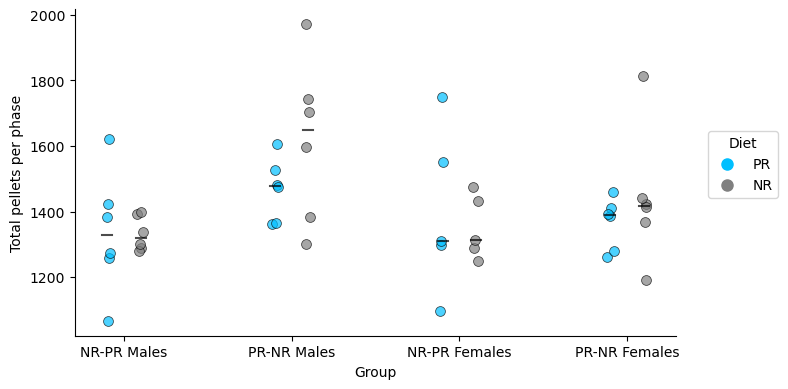

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = r'../results/FIVE/FEEDING_MICRO_PER_DAY_HOUR.csv'
data = pd.read_csv(file_path)

# Function to convert string representations of lists into actual lists
def convert_to_list(string):
    return eval(string) if isinstance(string, str) else string

# Convert the relevant columns into lists
data['pr_pellets_per_day'] = data['pr_pellets_per_day'].apply(convert_to_list)
data['nr_pellets_per_day'] = data['nr_pellets_per_day'].apply(convert_to_list)

# Grouping data by sex and order
nrpr_male_data = data[(data['sex'] == 'M') & (data['order'] == 1)]
prnr_male_data = data[(data['sex'] == 'M') & (data['order'] == 2)]
nrpr_female_data = data[(data['sex'] == 'F') & (data['order'] == 1)]
prnr_female_data = data[(data['sex'] == 'F') & (data['order'] == 2)]

# Sum the pellets per day for PR and NR for each group
nrpr_male_pr_pellets = nrpr_male_data['pr_pellets_per_day'].apply(sum).values
nrpr_male_nr_pellets = nrpr_male_data['nr_pellets_per_day'].apply(sum).values
prnr_male_pr_pellets = prnr_male_data['pr_pellets_per_day'].apply(sum).values
prnr_male_nr_pellets = prnr_male_data['nr_pellets_per_day'].apply(sum).values
nrpr_female_pr_pellets = nrpr_female_data['pr_pellets_per_day'].apply(sum).values
nrpr_female_nr_pellets = nrpr_female_data['nr_pellets_per_day'].apply(sum).values
prnr_female_pr_pellets = prnr_female_data['pr_pellets_per_day'].apply(sum).values
prnr_female_nr_pellets = prnr_female_data['nr_pellets_per_day'].apply(sum).values

# Combine all data for easier plotting
data = [nrpr_male_pr_pellets, nrpr_male_nr_pellets, prnr_male_pr_pellets, prnr_male_nr_pellets,
        nrpr_female_pr_pellets, nrpr_female_nr_pellets, prnr_female_pr_pellets, prnr_female_nr_pellets]

group_labels = ["NR-PR Males (PR)", "NR-PR Males (NR)", "PR-NR Males (PR)", "PR-NR Males (NR)",
                "NR-PR Females (PR)", "NR-PR Females (NR)", "PR-NR Females (PR)", "PR-NR Females (NR)"]

colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.1, "NR": 0.1}  # Reduced offset for compactness
group_mapping = {
    "NR-PR Males (PR)": ("NR-PR Males", "PR"),
    "NR-PR Males (NR)": ("NR-PR Males", "NR"),
    "PR-NR Males (PR)": ("PR-NR Males", "PR"),
    "PR-NR Males (NR)": ("PR-NR Males", "NR"),
    "NR-PR Females (PR)": ("NR-PR Females", "PR"),
    "NR-PR Females (NR)": ("NR-PR Females", "NR"),
    "PR-NR Females (PR)": ("PR-NR Females", "PR"),
    "PR-NR Females (NR)": ("PR-NR Females", "NR")
}

group_positions = {
    "NR-PR Males": 0,
    "PR-NR Males": 1,
    "NR-PR Females": 2,
    "PR-NR Females": 3
}

# Create a figure and axis with smaller size for compactness
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the scatter plot with reduced jitter and smaller markers
jitter_strength = 0.02  # Reduced jitter for more compact spacing
for i, group_label in enumerate(group_labels):
    group, diet = group_mapping[group_label]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(data[i]))
    x_positions = [group_positions[group] + offset[diet] + jitter_val for jitter_val in jitter]
    sns.scatterplot(x=x_positions, y=data[i], color=colors[diet], s=50, alpha=0.7, edgecolor="black", marker='o')

# Add median lines with slight adjustments for compactness
for group in ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"]:
    for diet in ["PR", "NR"]:
        relevant_data = []
        for group_label in group_labels:
            mapped_group, mapped_diet = group_mapping[group_label]
            if mapped_group == group and mapped_diet == diet:
                relevant_data.extend(data[group_labels.index(group_label)])
        median_value = np.median(relevant_data)
        x_val = group_positions[group] + offset[diet]
        ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize the legend by manually adding it
custom_lines = [plt.Line2D([0], [0], color=colors["PR"], marker='o', linestyle='', markersize=8, label='PR'),
                plt.Line2D([0], [0], color=colors["NR"], marker='o', linestyle='', markersize=8, label='NR')]
plt.legend(handles=custom_lines, title="Diet", loc="upper right", frameon=True, borderaxespad=-3, bbox_to_anchor=(1.1, 0.5))

# Customize the plot aesthetics with tighter spacing
plt.xticks([group_positions["NR-PR Males"], group_positions["PR-NR Males"],
            group_positions["NR-PR Females"], group_positions["PR-NR Females"]],
           ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Total pellets per phase")

# Remove the background grid lines and spines
plt.grid(False)
sns.despine()

plt.tight_layout()  # Adjust layout to fit labels
plt.show()


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


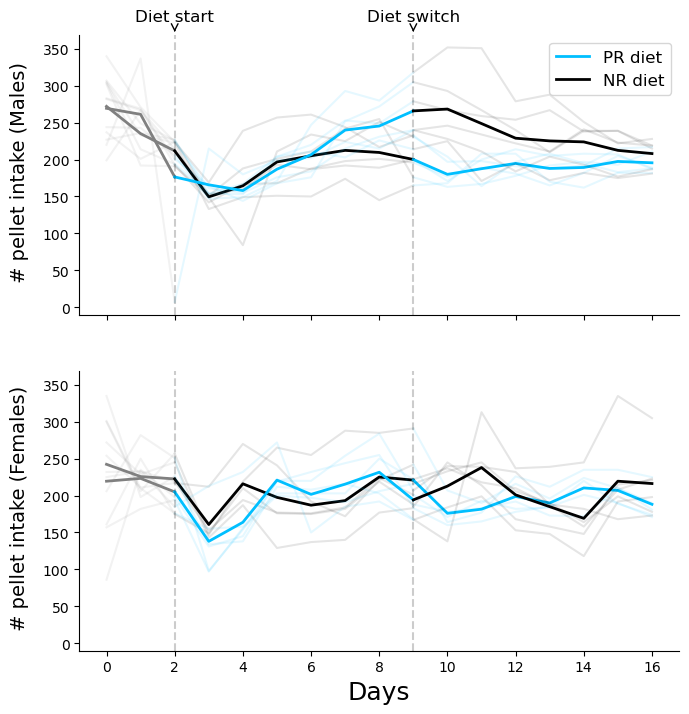

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot individual timelines
def timeline_fig(data, ax=[], ylabel="", **kwargs):
    if ax == []:
        f, ax = plt.subplots()  # Create a new figure and axis if none are provided
    
    for trace in data:
        ax.plot(trace, color="grey", alpha=0.3)  # Plot individual traces with transparency
    ax.plot(np.mean(data, axis=0), linewidth=2)  # Plot the mean line

    ax.set_ylabel(ylabel)
    ax.axvline(2, linestyle="--", color="k")  # Add vertical reference lines
    ax.axvline(9, linestyle="--", color="k")

    return ax

# Function to plot multicolored timeline with split phases (PR/NR)
def timeline_multicolor_fig(data, ax=[], ylabel="", colors=[], day_split=[2, 9], max_days=17, **kwargs):
    if ax == []:
        f, ax = plt.subplots()  # Create a new figure and axis if none are provided

    # Initialize lines for legend
    pr_line = None
    nr_line = None

    for group in data:
        for trace in group:
            trace = trace[:max_days]  # Ensure the trace is within the max_days range
            ax.plot(range(0, 3), trace[:3], color="grey", alpha=0.1)  # Plot the grey phase
            ax.plot(range(2, 10), trace[2:10], color=colors[0], alpha=0.1)  # First phase in color (PR diet)
            ax.plot(range(9, len(trace)), trace[9:], color=colors[1], alpha=0.1)  # Second phase in color (NR diet)

        # Plot the mean values and store lines for the legend
        mean = np.mean(group, axis=0)[:max_days]
        ax.plot(range(0, 3), mean[:3], color="grey", linewidth=2)  # Grey phase mean
        pr_line, = ax.plot(range(2, 10), mean[2:10], color=colors[0], linewidth=2, label="PR diet")  # First phase mean
        nr_line, = ax.plot(range(9, len(mean)), mean[9:], color=colors[1], linewidth=2, label="NR diet")  # Second phase mean

        colors.reverse()  # Alternate color for next group

    ax.set_ylabel(ylabel, fontsize=14, labelpad=10)  # Add label padding to avoid overlap
    ax.axvline(2, linestyle="--", color="k", alpha=0.2)  # Add phase split lines
    ax.axvline(9, linestyle="--", color="k", alpha=0.2)

    # Remove the upper and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax, pr_line, nr_line

# Selectors for grouping mice data
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}

# Get data for mega meals per day
nrpr_m_mega_meals = get_data_fields(mice, ["all_pellets_per_day"], nrpr_male_selector)
prnr_m_mega_meals = get_data_fields(mice, ["all_pellets_per_day"], prnr_male_selector)
nrpr_f_mega_meals = get_data_fields(mice, ["all_pellets_per_day"], nrpr_female_selector)
prnr_f_mega_meals = get_data_fields(mice, ["all_pellets_per_day"], prnr_female_selector)

# Increase figure size and adjust font sizes to avoid overlap
f, ax = plt.subplots(nrows=2, sharex=True, figsize=(8, 8), gridspec_kw={"left": 0.15})

# Plot for males with annotations only on the upper plot
_, pr_line, nr_line = timeline_multicolor_fig([nrpr_m_mega_meals, prnr_m_mega_meals], colors=["black", "deepskyblue"], ylabel=" # pellet intake (Males)", ax=ax[0])

# Add annotations at day 2 and day 9 only on the upper plot
ax[0].annotate('Diet start', xy=(2, ax[0].get_ylim()[1]), xytext=(2, ax[0].get_ylim()[1] + 0.05 * ax[0].get_ylim()[1]), 
               ha='center', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax[0].annotate('Diet switch', xy=(9, ax[0].get_ylim()[1]), xytext=(9, ax[0].get_ylim()[1] + 0.05 * ax[0].get_ylim()[1]), 
               ha='center', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))

# Plot for females
timeline_multicolor_fig([nrpr_f_mega_meals, prnr_f_mega_meals], colors=["black", "deepskyblue"], ylabel=" # pellet intake (Females)", ax=ax[1])

# Set common X-axis label
ax[1].set_xlabel("Days", fontsize=18)

# Set a common Y-axis limit for better comparison
ax[1].set_ylim(ax[0].get_ylim())

# Add legend for PR and NR diet (PR = deepskyblue, NR = black)
ax[0].legend([pr_line, nr_line], ["PR diet", "NR diet"], loc="upper right", fontsize=12)

# Show the plot
plt.show()

# Save the figure if needed
figfolder = r"..//plots/NEW_MEAL_PLOTS//"
# f.savefig(figfolder + "timeline_mega_meals_per_day.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


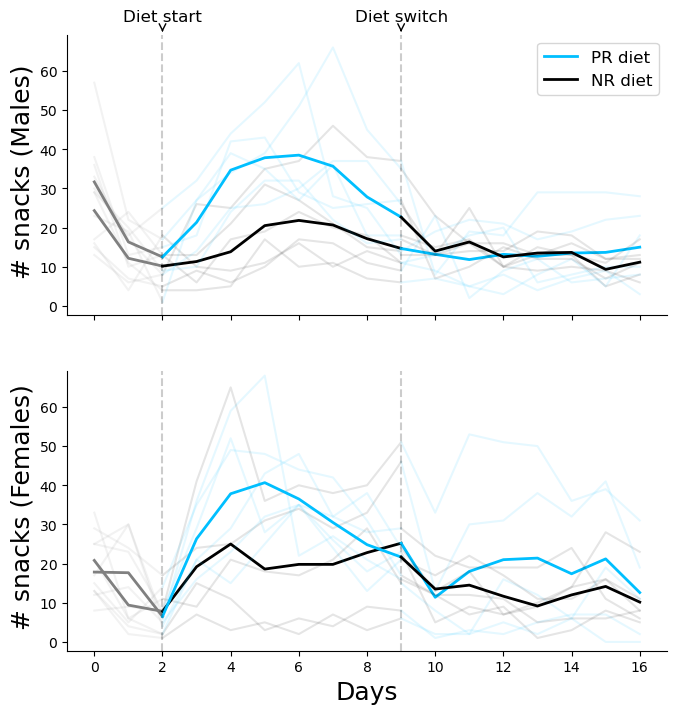

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot individual timelines
def timeline_fig(data, ax=[], ylabel="", **kwargs):
    if ax == []:
        f, ax = plt.subplots()  # Create a new figure and axis if none are provided
    
    for trace in data:
        ax.plot(trace, color="grey", alpha=0.3)  # Plot individual traces with transparency
    ax.plot(np.mean(data, axis=0), linewidth=2)  # Plot the mean line

    ax.set_ylabel(ylabel)
    ax.axvline(2, linestyle="--", color="k")  # Add vertical reference lines
    ax.axvline(9, linestyle="--", color="k")

    return ax

# Function to plot multicolored timeline with split phases (PR/NR)
def timeline_multicolor_fig(data, ax=[], ylabel="", colors=[], day_split=[2, 9], max_days=17, **kwargs):
    if ax == []:
        f, ax = plt.subplots()  # Create a new figure and axis if none are provided

    # Initialize lines for legend
    pr_line = None
    nr_line = None

    for group in data:
        for trace in group:
            trace = trace[:max_days]  # Ensure the trace is within the max_days range
            ax.plot(range(0, 3), trace[:3], color="grey", alpha=0.1)  # Plot the grey phase
            ax.plot(range(2, 10), trace[2:10], color=colors[1], alpha=0.1)  # First phase in color (PR diet)
            ax.plot(range(9, len(trace)), trace[9:], color=colors[0], alpha=0.1)  # Second phase in color (NR diet)

        # Plot the mean values and store lines for the legend
        mean = np.mean(group, axis=0)[:max_days]
        ax.plot(range(0, 3), mean[:3], color="grey", linewidth=2)  # Grey phase mean
        pr_line, = ax.plot(range(2, 10), mean[2:10], color=colors[1], linewidth=2, label="PR diet")  # First phase mean
        nr_line, = ax.plot(range(9, len(mean)), mean[9:], color=colors[0], linewidth=2, label="NR diet")  # Second phase mean

        colors.reverse()  # Alternate color for next group

    ax.set_ylabel(ylabel, fontsize=18)
    ax.axvline(2, linestyle="--", color="k", alpha=0.2)  # Add phase split lines
    ax.axvline(9, linestyle="--", color="k", alpha=0.2)

    # Remove the upper and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax, pr_line, nr_line

# Selectors for grouping mice data
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}

# Get data for mega meals per day
nrpr_m_mega_meals = get_data_fields(mice, ["all_snacks_per_day"], nrpr_male_selector)
prnr_m_mega_meals = get_data_fields(mice, ["all_snacks_per_day"], prnr_male_selector)
nrpr_f_mega_meals = get_data_fields(mice, ["all_snacks_per_day"], nrpr_female_selector)
prnr_f_mega_meals = get_data_fields(mice, ["all_snacks_per_day"], prnr_female_selector)

# Increase figure size and adjust font sizes to avoid overlap
f, ax = plt.subplots(nrows=2, sharex=True, figsize=(8, 8), gridspec_kw={"left": 0.15})

# Plot for males with annotations only on the upper plot
_, pr_line, nr_line = timeline_multicolor_fig([nrpr_m_mega_meals, prnr_m_mega_meals], colors=["deepskyblue", "black"], ylabel=" # snacks (Males)", ax=ax[0])

# Add annotations at day 2 and day 9 only on the upper plot
ax[0].annotate('Diet start', xy=(2, ax[0].get_ylim()[1]), xytext=(2, ax[0].get_ylim()[1] + 0.05 * ax[0].get_ylim()[1]), 
               ha='center', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax[0].annotate('Diet switch', xy=(9, ax[0].get_ylim()[1]), xytext=(9, ax[0].get_ylim()[1] + 0.05 * ax[0].get_ylim()[1]), 
               ha='center', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))

# Plot for females
timeline_multicolor_fig([nrpr_f_mega_meals, prnr_f_mega_meals], colors=["deepskyblue", "black"], ylabel=" # snacks (Females)", ax=ax[1])

# Set common X-axis label
ax[1].set_xlabel("Days", fontsize=18)

# Set a common Y-axis limit for better comparison
ax[1].set_ylim(ax[0].get_ylim())

# Add legend for PR and NR diet (PR = deepskyblue, NR = black)
ax[0].legend([pr_line, nr_line], ["PR diet", "NR diet"], loc="upper right", fontsize=12)

# Show the plot
plt.show()

# Save the figure if needed
figfolder = r"..//plots/NEW_MEAL_PLOTS//"
# f.savefig(figfolder + "timeline_snacks_per_day.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


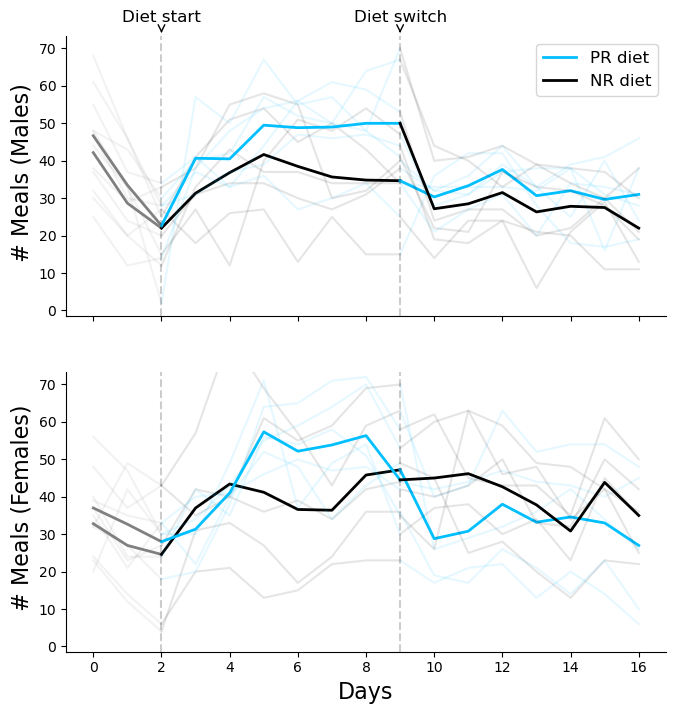

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot individual timelines
def timeline_fig(data, ax=[], ylabel="", **kwargs):
    if ax == []:
        f, ax = plt.subplots()  # Create a new figure and axis if none are provided
    
    for trace in data:
        ax.plot(trace, color="grey", alpha=0.3)  # Plot individual traces with transparency
    ax.plot(np.mean(data, axis=0), linewidth=2)  # Plot the mean line

    ax.set_ylabel(ylabel)
    ax.axvline(2, linestyle="--", color="k")  # Add vertical reference lines
    ax.axvline(9, linestyle="--", color="k")

    return ax

# Function to plot multicolored timeline with split phases (PR/NR)
def timeline_multicolor_fig(data, ax=[], ylabel="", colors=[], day_split=[2, 9], max_days=17, **kwargs):
    if ax == []:
        f, ax = plt.subplots()  # Create a new figure and axis if none are provided

    # Initialize lines for legend
    pr_line = None
    nr_line = None

    for group in data:
        for trace in group:
            trace = trace[:max_days]  # Ensure the trace is within the max_days range
            ax.plot(range(0, 3), trace[:3], color="grey", alpha=0.1)  # Plot the grey phase
            ax.plot(range(2, 10), trace[2:10], color=colors[0], alpha=0.1)  # First phase in color (PR diet)
            ax.plot(range(9, len(trace)), trace[9:], color=colors[1], alpha=0.1)  # Second phase in color (NR diet)

        # Plot the mean values and store lines for the legend
        mean = np.mean(group, axis=0)[:max_days]
        ax.plot(range(0, 3), mean[:3], color="grey", linewidth=2)  # Grey phase mean
        pr_line, = ax.plot(range(2, 10), mean[2:10], color=colors[0], linewidth=2, label="PR diet")  # First phase mean
        nr_line, = ax.plot(range(9, len(mean)), mean[9:], color=colors[1], linewidth=2, label="NR diet")  # Second phase mean

        colors.reverse()  # Alternate color for next group

    ax.set_ylabel(ylabel, fontsize=16)  # Reduced font size
    ax.axvline(2, linestyle="--", color="k", alpha=0.2)  # Add phase split lines
    ax.axvline(9, linestyle="--", color="k", alpha=0.2)

    # Add annotations at day 2 and day 9
    ax.annotate('Diet start', xy=(2, ax.get_ylim()[1]), xytext=(2, ax.get_ylim()[1] + 0.05 * ax.get_ylim()[1]), 
                ha='center', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))
    ax.annotate('Diet switch', xy=(9, ax.get_ylim()[1]), xytext=(9, ax.get_ylim()[1] + 0.05 * ax.get_ylim()[1]), 
                ha='center', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))

    # Remove the upper and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax, pr_line, nr_line

# Selectors for grouping mice data
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}

# Get data for mega meals per day
nrpr_m_mega_meals = get_data_fields(mice, ["all_meals_per_day"], nrpr_male_selector)
prnr_m_mega_meals = get_data_fields(mice, ["all_meals_per_day"], prnr_male_selector)
nrpr_f_mega_meals = get_data_fields(mice, ["all_meals_per_day"], nrpr_female_selector)
prnr_f_mega_meals = get_data_fields(mice, ["all_meals_per_day"], prnr_female_selector)

# Increase figure size and adjust font sizes to avoid overlap
f, ax = plt.subplots(nrows=2, sharex=True, figsize=(8, 8), gridspec_kw={"left": 0.15})

# Plot for males
_, pr_line, nr_line = timeline_multicolor_fig([nrpr_m_mega_meals, prnr_m_mega_meals], colors=["black", "deepskyblue"], ylabel=" # Meals (Males)", ax=ax[0])

# Plot for females
timeline_multicolor_fig([nrpr_f_mega_meals, prnr_f_mega_meals], colors=["black", "deepskyblue"], ylabel=" # Meals (Females)", ax=ax[1])

# Set common X-axis label
ax[1].set_xlabel("Days", fontsize=16)

# Set a common Y-axis limit for better comparison
ax[1].set_ylim(ax[0].get_ylim())

# Add legend for PR and NR diet
ax[0].legend([pr_line, nr_line], ["PR diet", "NR diet"], loc="upper right", fontsize=12)

# Show the plot
plt.show()

# Save the figure if needed
figfolder = r"..//plots/NEW_MEAL_PLOTS//"
# f.savefig(figfolder + "timeline_mega_meals_per_day.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


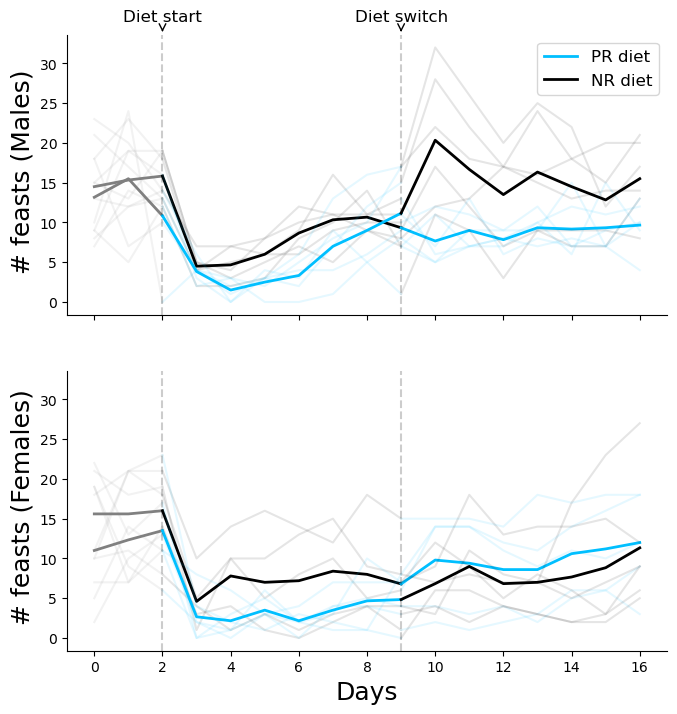

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot individual timelines
def timeline_fig(data, ax=[], ylabel="", **kwargs):
    if ax == []:
        f, ax = plt.subplots()  # Create a new figure and axis if none are provided
    
    for trace in data:
        ax.plot(trace, color="grey", alpha=0.3)  # Plot individual traces with transparency
    ax.plot(np.mean(data, axis=0), linewidth=2)  # Plot the mean line

    ax.set_ylabel(ylabel)
    ax.axvline(2, linestyle="--", color="k")  # Add vertical reference lines
    ax.axvline(9, linestyle="--", color="k")

    return ax

# Function to plot multicolored timeline with split phases (PR/NR)
def timeline_multicolor_fig(data, ax=[], ylabel="", colors=[], day_split=[2, 9], max_days=17, **kwargs):
    if ax == []:
        f, ax = plt.subplots()  # Create a new figure and axis if none are provided

    # Initialize lines for legend
    pr_line = None
    nr_line = None

    for group in data:
        for trace in group:
            trace = trace[:max_days]  # Ensure the trace is within the max_days range
            ax.plot(range(0, 3), trace[:3], color="grey", alpha=0.1)  # Plot the grey phase
            ax.plot(range(2, 10), trace[2:10], color=colors[1], alpha=0.1)  # First phase in color (PR diet)
            ax.plot(range(9, len(trace)), trace[9:], color=colors[0], alpha=0.1)  # Second phase in color (NR diet)

        # Plot the mean values and store lines for the legend
        mean = np.mean(group, axis=0)[:max_days]
        ax.plot(range(0, 3), mean[:3], color="grey", linewidth=2)  # Grey phase mean
        pr_line, = ax.plot(range(2, 10), mean[2:10], color=colors[1], linewidth=2, label="PR diet")  # First phase mean
        nr_line, = ax.plot(range(9, len(mean)), mean[9:], color=colors[0], linewidth=2, label="NR diet")  # Second phase mean

        colors.reverse()  # Alternate color for next group

    ax.set_ylabel(ylabel, fontsize=18)
    ax.axvline(2, linestyle="--", color="k", alpha=0.2)  # Add phase split lines
    ax.axvline(9, linestyle="--", color="k", alpha=0.2)

    # Remove the upper and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax, pr_line, nr_line

# Selectors for grouping mice data
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}

# Get data for mega meals per day
nrpr_m_mega_meals = get_data_fields(mice, ["all_mega_meals_per_day"], nrpr_male_selector)
prnr_m_mega_meals = get_data_fields(mice, ["all_mega_meals_per_day"], prnr_male_selector)
nrpr_f_mega_meals = get_data_fields(mice, ["all_mega_meals_per_day"], nrpr_female_selector)
prnr_f_mega_meals = get_data_fields(mice, ["all_mega_meals_per_day"], prnr_female_selector)

# Increase figure size and adjust font sizes to avoid overlap
f, ax = plt.subplots(nrows=2, sharex=True, figsize=(8, 8), gridspec_kw={"left": 0.15})

# Plot for males with annotations only on the upper plot
_, pr_line, nr_line = timeline_multicolor_fig([nrpr_m_mega_meals, prnr_m_mega_meals], colors=["deepskyblue", "black"], ylabel=" # feasts (Males)", ax=ax[0])

# Add annotations at day 2 and day 9 only on the upper plot
ax[0].annotate('Diet start', xy=(2, ax[0].get_ylim()[1]), xytext=(2, ax[0].get_ylim()[1] + 0.05 * ax[0].get_ylim()[1]), 
               ha='center', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax[0].annotate('Diet switch', xy=(9, ax[0].get_ylim()[1]), xytext=(9, ax[0].get_ylim()[1] + 0.05 * ax[0].get_ylim()[1]), 
               ha='center', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))

# Plot for females
timeline_multicolor_fig([nrpr_f_mega_meals, prnr_f_mega_meals], colors=["deepskyblue", "black"], ylabel=" # feasts (Females)", ax=ax[1])

# Set common X-axis label
ax[1].set_xlabel("Days", fontsize=18)

# Set a common Y-axis limit for better comparison
ax[1].set_ylim(ax[0].get_ylim())

# Add legend for PR and NR diet (PR = deepskyblue, NR = black)
ax[0].legend([pr_line, nr_line], ["PR diet", "NR diet"], loc="upper right", fontsize=12)

# Show the plot
plt.show()

# Save the figure if needed
figfolder = r"..//plots/NEW_MEAL_PLOTS//"
# f.savefig(figfolder + "timeline_mega_meals_per_day.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


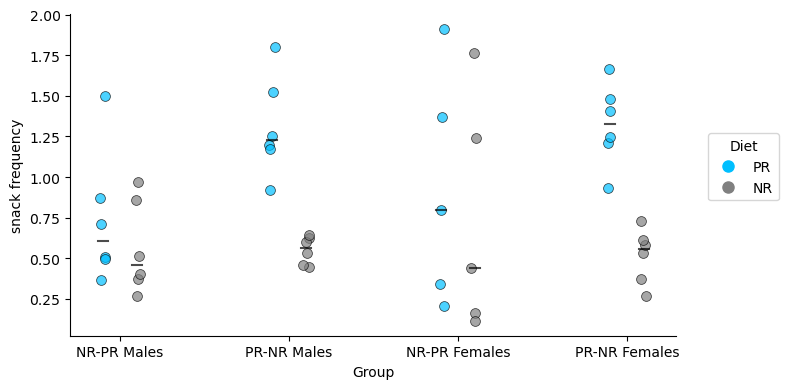

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data extraction using your actual function
nrpr_avg = get_data_fields(mice, ["pr_snack_frequency","nr_snack_frequency"], nrpr_male_selector)
prnr_avg = get_data_fields(mice, ["pr_snack_frequency", "nr_snack_frequency"], prnr_male_selector)
nrprf_avg = get_data_fields(mice, ["pr_snack_frequency","nr_snack_frequency"], nrpr_female_selector)
prnrf_avg = get_data_fields(mice, ["pr_snack_frequency","nr_snack_frequency"], prnr_female_selector)

# Combine all data for easier plotting
data = [nrpr_avg[0], nrpr_avg[1], prnr_avg[0], prnr_avg[1],
        nrprf_avg[0], nrprf_avg[1], prnrf_avg[0], prnrf_avg[1]]

group_labels = ["NR-PR Males (PR)", "NR-PR Males (NR)", "PR-NR Males (PR)", "PR-NR Males (NR)",
                "NR-PR Females (PR)", "NR-PR Females (NR)", "PR-NR Females (PR)", "PR-NR Females (NR)"]

colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.1, "NR": 0.1}  # Reduced offset for compactness
group_mapping = {
    "NR-PR Males (PR)": ("NR-PR Males", "PR"),
    "NR-PR Males (NR)": ("NR-PR Males", "NR"),
    "PR-NR Males (PR)": ("PR-NR Males", "PR"),
    "PR-NR Males (NR)": ("PR-NR Males", "NR"),
    "NR-PR Females (PR)": ("NR-PR Females", "PR"),
    "NR-PR Females (NR)": ("NR-PR Females", "NR"),
    "PR-NR Females (PR)": ("PR-NR Females", "PR"),
    "PR-NR Females (NR)": ("PR-NR Females", "NR")
}

group_positions = {
    "NR-PR Males": 0,
    "PR-NR Males": 1,
    "NR-PR Females": 2,
    "PR-NR Females": 3
}

# Create a figure and axis with smaller size for compactness
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the scatter plot with reduced jitter and smaller markers
jitter_strength = 0.02  # Reduced jitter for more compact spacing
for i, group_label in enumerate(group_labels):
    group, diet = group_mapping[group_label]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(data[i]))
    x_positions = [group_positions[group] + offset[diet] + jitter_val for jitter_val in jitter]
    sns.scatterplot(x=x_positions, y=data[i], color=colors[diet], s=50, alpha=0.7, edgecolor="black")  # Smaller markers

# Add median lines with slight adjustments for compactness
for group in ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"]:
    for diet in ["PR", "NR"]:
        relevant_data = []
        for group_label in group_labels:
            mapped_group, mapped_diet = group_mapping[group_label]
            if mapped_group == group and mapped_diet == diet:
                relevant_data.extend(data[group_labels.index(group_label)])
        median_value = np.median(relevant_data)
        x_val = group_positions[group] + offset[diet]
        ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize the legend by manually adding it
custom_lines = [plt.Line2D([0], [0], color=colors["PR"], marker='o', linestyle='', markersize=8, label='PR'),
                plt.Line2D([0], [0], color=colors["NR"], marker='o', linestyle='', markersize=8, label='NR')]
plt.legend(handles=custom_lines, title="Diet", loc="upper right", frameon=True, borderaxespad=-3, bbox_to_anchor=(1.1, 0.5))

# Customize the plot aesthetics with tighter spacing
plt.xticks([group_positions["NR-PR Males"], group_positions["PR-NR Males"],
            group_positions["NR-PR Females"], group_positions["PR-NR Females"]],
           ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("snack frequency")

# Remove the background grid lines and spines
plt.grid(False)
sns.despine()

plt.tight_layout()  # Adjust layout to fit labels
plt.show()

# Save the figure if needed
# fig.savefig("pellets_scatter_plot_compact.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


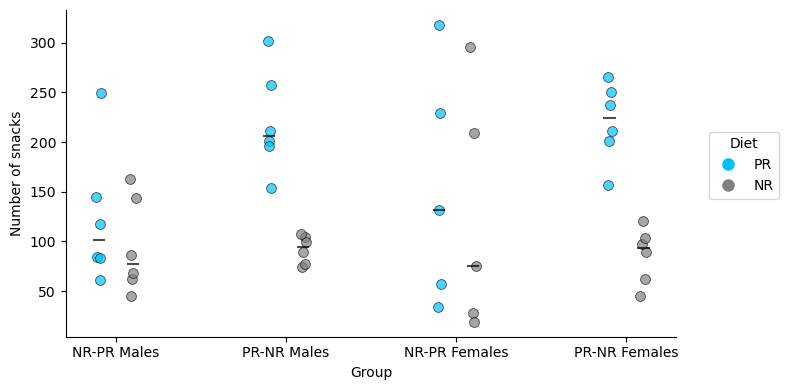

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data extraction using your actual function
nrpr_avg = get_data_fields(mice, ["pr_number_of_snacks","nr_number_of_snacks"], nrpr_male_selector)
prnr_avg = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], prnr_male_selector)
nrprf_avg = get_data_fields(mice, ["pr_number_of_snacks","nr_number_of_snacks"], nrpr_female_selector)
prnrf_avg = get_data_fields(mice, ["pr_number_of_snacks","nr_number_of_snacks"], prnr_female_selector)

# Combine all data for easier plotting
data = [nrpr_avg[0], nrpr_avg[1], prnr_avg[0], prnr_avg[1],
        nrprf_avg[0], nrprf_avg[1], prnrf_avg[0], prnrf_avg[1]]

group_labels = ["NR-PR Males (PR)", "NR-PR Males (NR)", "PR-NR Males (PR)", "PR-NR Males (NR)",
                "NR-PR Females (PR)", "NR-PR Females (NR)", "PR-NR Females (PR)", "PR-NR Females (NR)"]

colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.1, "NR": 0.1}  # Reduced offset for compactness
group_mapping = {
    "NR-PR Males (PR)": ("NR-PR Males", "PR"),
    "NR-PR Males (NR)": ("NR-PR Males", "NR"),
    "PR-NR Males (PR)": ("PR-NR Males", "PR"),
    "PR-NR Males (NR)": ("PR-NR Males", "NR"),
    "NR-PR Females (PR)": ("NR-PR Females", "PR"),
    "NR-PR Females (NR)": ("NR-PR Females", "NR"),
    "PR-NR Females (PR)": ("PR-NR Females", "PR"),
    "PR-NR Females (NR)": ("PR-NR Females", "NR")
}

group_positions = {
    "NR-PR Males": 0,
    "PR-NR Males": 1,
    "NR-PR Females": 2,
    "PR-NR Females": 3
}

# Create a figure and axis with smaller size for compactness
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the scatter plot with reduced jitter and smaller markers
jitter_strength = 0.02  # Reduced jitter for more compact spacing
for i, group_label in enumerate(group_labels):
    group, diet = group_mapping[group_label]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(data[i]))
    x_positions = [group_positions[group] + offset[diet] + jitter_val for jitter_val in jitter]
    sns.scatterplot(x=x_positions, y=data[i], color=colors[diet], s=50, alpha=0.7, edgecolor="black")  # Smaller markers

# Add median lines with slight adjustments for compactness
for group in ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"]:
    for diet in ["PR", "NR"]:
        relevant_data = []
        for group_label in group_labels:
            mapped_group, mapped_diet = group_mapping[group_label]
            if mapped_group == group and mapped_diet == diet:
                relevant_data.extend(data[group_labels.index(group_label)])
        median_value = np.median(relevant_data)
        x_val = group_positions[group] + offset[diet]
        ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize the legend by manually adding it
custom_lines = [plt.Line2D([0], [0], color=colors["PR"], marker='o', linestyle='', markersize=8, label='PR'),
                plt.Line2D([0], [0], color=colors["NR"], marker='o', linestyle='', markersize=8, label='NR')]
plt.legend(handles=custom_lines, title="Diet", loc="upper right", frameon=True, borderaxespad=-3, bbox_to_anchor=(1.1, 0.5))

# Customize the plot aesthetics with tighter spacing
plt.xticks([group_positions["NR-PR Males"], group_positions["PR-NR Males"],
            group_positions["NR-PR Females"], group_positions["PR-NR Females"]],
           ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Number of snacks")

# Remove the background grid lines and spines
plt.grid(False)
sns.despine()

plt.tight_layout()  # Adjust layout to fit labels
plt.show()

# Save the figure if needed
# fig.savefig("pellets_scatter_plot_compact.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


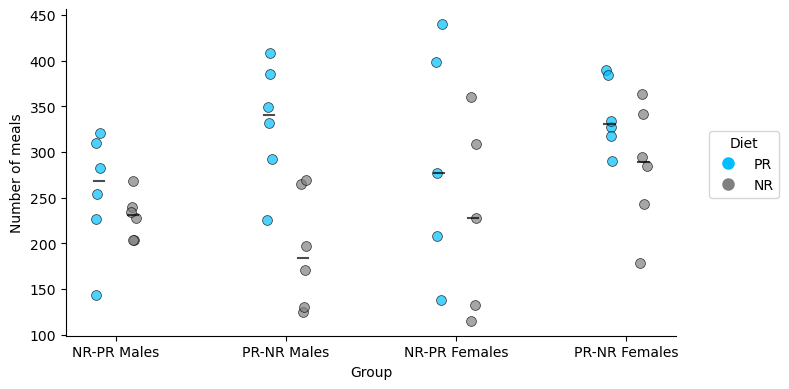

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data extraction using your actual function
nrpr_avg = get_data_fields(mice, ["pr_number_of_meals","nr_number_of_meals"], nrpr_male_selector)
prnr_avg = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], prnr_male_selector)
nrprf_avg = get_data_fields(mice, ["pr_number_of_meals","nr_number_of_meals"], nrpr_female_selector)
prnrf_avg = get_data_fields(mice, ["pr_number_of_meals","nr_number_of_meals"], prnr_female_selector)

# Combine all data for easier plotting
data = [nrpr_avg[0], nrpr_avg[1], prnr_avg[0], prnr_avg[1],
        nrprf_avg[0], nrprf_avg[1], prnrf_avg[0], prnrf_avg[1]]

group_labels = ["NR-PR Males (PR)", "NR-PR Males (NR)", "PR-NR Males (PR)", "PR-NR Males (NR)",
                "NR-PR Females (PR)", "NR-PR Females (NR)", "PR-NR Females (PR)", "PR-NR Females (NR)"]

colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.1, "NR": 0.1}  # Reduced offset for compactness
group_mapping = {
    "NR-PR Males (PR)": ("NR-PR Males", "PR"),
    "NR-PR Males (NR)": ("NR-PR Males", "NR"),
    "PR-NR Males (PR)": ("PR-NR Males", "PR"),
    "PR-NR Males (NR)": ("PR-NR Males", "NR"),
    "NR-PR Females (PR)": ("NR-PR Females", "PR"),
    "NR-PR Females (NR)": ("NR-PR Females", "NR"),
    "PR-NR Females (PR)": ("PR-NR Females", "PR"),
    "PR-NR Females (NR)": ("PR-NR Females", "NR")
}

group_positions = {
    "NR-PR Males": 0,
    "PR-NR Males": 1,
    "NR-PR Females": 2,
    "PR-NR Females": 3
}

# Create a figure and axis with smaller size for compactness
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the scatter plot with reduced jitter and smaller markers
jitter_strength = 0.02  # Reduced jitter for more compact spacing
for i, group_label in enumerate(group_labels):
    group, diet = group_mapping[group_label]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(data[i]))
    x_positions = [group_positions[group] + offset[diet] + jitter_val for jitter_val in jitter]
    sns.scatterplot(x=x_positions, y=data[i], color=colors[diet], s=50, alpha=0.7, edgecolor="black")  # Smaller markers

# Add median lines with slight adjustments for compactness
for group in ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"]:
    for diet in ["PR", "NR"]:
        relevant_data = []
        for group_label in group_labels:
            mapped_group, mapped_diet = group_mapping[group_label]
            if mapped_group == group and mapped_diet == diet:
                relevant_data.extend(data[group_labels.index(group_label)])
        median_value = np.median(relevant_data)
        x_val = group_positions[group] + offset[diet]
        ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize the legend by manually adding it
custom_lines = [plt.Line2D([0], [0], color=colors["PR"], marker='o', linestyle='', markersize=8, label='PR'),
                plt.Line2D([0], [0], color=colors["NR"], marker='o', linestyle='', markersize=8, label='NR')]
plt.legend(handles=custom_lines, title="Diet", loc="upper right", frameon=True, borderaxespad=-3, bbox_to_anchor=(1.1, 0.5))

# Customize the plot aesthetics with tighter spacing
plt.xticks([group_positions["NR-PR Males"], group_positions["PR-NR Males"],
            group_positions["NR-PR Females"], group_positions["PR-NR Females"]],
           ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Number of meals")

# Remove the background grid lines and spines
plt.grid(False)
sns.despine()

plt.tight_layout()  # Adjust layout to fit labels
plt.show()

# Save the figure if needed
# fig.savefig("pellets_scatter_plot_compact.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


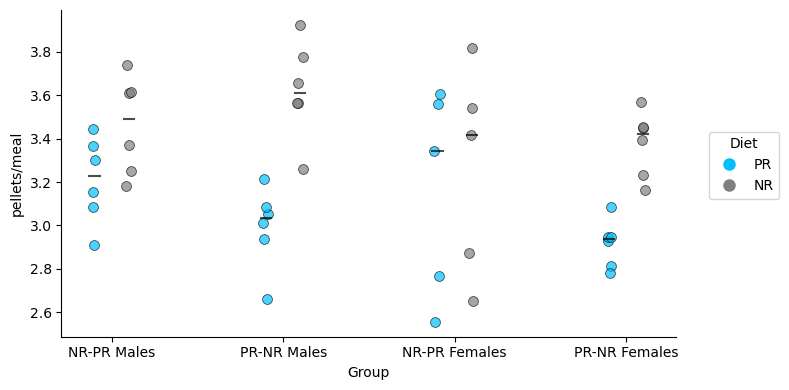

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data extraction using your actual function
nrpr_avg = get_data_fields(mice, ["pr_meal_size","nr_meal_size"], nrpr_male_selector)
prnr_avg = get_data_fields(mice, ["pr_meal_size", "nr_meal_size"], prnr_male_selector)
nrprf_avg = get_data_fields(mice, ["pr_meal_size","nr_meal_size"], nrpr_female_selector)
prnrf_avg = get_data_fields(mice, ["pr_meal_size","nr_meal_size"], prnr_female_selector)

# Combine all data for easier plotting
data = [nrpr_avg[0], nrpr_avg[1], prnr_avg[0], prnr_avg[1],
        nrprf_avg[0], nrprf_avg[1], prnrf_avg[0], prnrf_avg[1]]

group_labels = ["NR-PR Males (PR)", "NR-PR Males (NR)", "PR-NR Males (PR)", "PR-NR Males (NR)",
                "NR-PR Females (PR)", "NR-PR Females (NR)", "PR-NR Females (PR)", "PR-NR Females (NR)"]

colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.1, "NR": 0.1}  # Reduced offset for compactness
group_mapping = {
    "NR-PR Males (PR)": ("NR-PR Males", "PR"),
    "NR-PR Males (NR)": ("NR-PR Males", "NR"),
    "PR-NR Males (PR)": ("PR-NR Males", "PR"),
    "PR-NR Males (NR)": ("PR-NR Males", "NR"),
    "NR-PR Females (PR)": ("NR-PR Females", "PR"),
    "NR-PR Females (NR)": ("NR-PR Females", "NR"),
    "PR-NR Females (PR)": ("PR-NR Females", "PR"),
    "PR-NR Females (NR)": ("PR-NR Females", "NR")
}

group_positions = {
    "NR-PR Males": 0,
    "PR-NR Males": 1,
    "NR-PR Females": 2,
    "PR-NR Females": 3
}

# Create a figure and axis with smaller size for compactness
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the scatter plot with reduced jitter and smaller markers
jitter_strength = 0.02  # Reduced jitter for more compact spacing
for i, group_label in enumerate(group_labels):
    group, diet = group_mapping[group_label]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(data[i]))
    x_positions = [group_positions[group] + offset[diet] + jitter_val for jitter_val in jitter]
    sns.scatterplot(x=x_positions, y=data[i], color=colors[diet], s=50, alpha=0.7, edgecolor="black")  # Smaller markers

# Add median lines with slight adjustments for compactness
for group in ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"]:
    for diet in ["PR", "NR"]:
        relevant_data = []
        for group_label in group_labels:
            mapped_group, mapped_diet = group_mapping[group_label]
            if mapped_group == group and mapped_diet == diet:
                relevant_data.extend(data[group_labels.index(group_label)])
        median_value = np.median(relevant_data)
        x_val = group_positions[group] + offset[diet]
        ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize the legend by manually adding it
custom_lines = [plt.Line2D([0], [0], color=colors["PR"], marker='o', linestyle='', markersize=8, label='PR'),
                plt.Line2D([0], [0], color=colors["NR"], marker='o', linestyle='', markersize=8, label='NR')]
plt.legend(handles=custom_lines, title="Diet", loc="upper right", frameon=True, borderaxespad=-3, bbox_to_anchor=(1.1, 0.5))

# Customize the plot aesthetics with tighter spacing
plt.xticks([group_positions["NR-PR Males"], group_positions["PR-NR Males"],
            group_positions["NR-PR Females"], group_positions["PR-NR Females"]],
           ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("pellets/meal")

# Remove the background grid lines and spines
plt.grid(False)
sns.despine()

plt.tight_layout()  # Adjust layout to fit labels
plt.show()

# Save the figure if needed
# fig.savefig("pellets_scatter_plot_compact.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


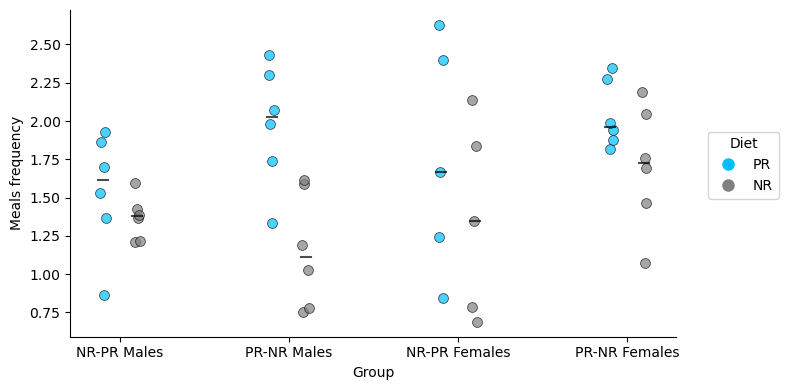

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data extraction using your actual function
nrpr_avg = get_data_fields(mice, ["pr_meal_frequency","nr_meal_frequency"], nrpr_male_selector)
prnr_avg = get_data_fields(mice, ["pr_meal_frequency", "nr_meal_frequency"], prnr_male_selector)
nrprf_avg = get_data_fields(mice, ["pr_meal_frequency","nr_meal_frequency"], nrpr_female_selector)
prnrf_avg = get_data_fields(mice, ["pr_meal_frequency","nr_meal_frequency"], prnr_female_selector)

# Combine all data for easier plotting
data = [nrpr_avg[0], nrpr_avg[1], prnr_avg[0], prnr_avg[1],
        nrprf_avg[0], nrprf_avg[1], prnrf_avg[0], prnrf_avg[1]]

group_labels = ["NR-PR Males (PR)", "NR-PR Males (NR)", "PR-NR Males (PR)", "PR-NR Males (NR)",
                "NR-PR Females (PR)", "NR-PR Females (NR)", "PR-NR Females (PR)", "PR-NR Females (NR)"]

colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.1, "NR": 0.1}  # Reduced offset for compactness
group_mapping = {
    "NR-PR Males (PR)": ("NR-PR Males", "PR"),
    "NR-PR Males (NR)": ("NR-PR Males", "NR"),
    "PR-NR Males (PR)": ("PR-NR Males", "PR"),
    "PR-NR Males (NR)": ("PR-NR Males", "NR"),
    "NR-PR Females (PR)": ("NR-PR Females", "PR"),
    "NR-PR Females (NR)": ("NR-PR Females", "NR"),
    "PR-NR Females (PR)": ("PR-NR Females", "PR"),
    "PR-NR Females (NR)": ("PR-NR Females", "NR")
}

group_positions = {
    "NR-PR Males": 0,
    "PR-NR Males": 1,
    "NR-PR Females": 2,
    "PR-NR Females": 3
}

# Create a figure and axis with smaller size for compactness
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the scatter plot with reduced jitter and smaller markers
jitter_strength = 0.02  # Reduced jitter for more compact spacing
for i, group_label in enumerate(group_labels):
    group, diet = group_mapping[group_label]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(data[i]))
    x_positions = [group_positions[group] + offset[diet] + jitter_val for jitter_val in jitter]
    sns.scatterplot(x=x_positions, y=data[i], color=colors[diet], s=50, alpha=0.7, edgecolor="black")  # Smaller markers

# Add median lines with slight adjustments for compactness
for group in ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"]:
    for diet in ["PR", "NR"]:
        relevant_data = []
        for group_label in group_labels:
            mapped_group, mapped_diet = group_mapping[group_label]
            if mapped_group == group and mapped_diet == diet:
                relevant_data.extend(data[group_labels.index(group_label)])
        median_value = np.median(relevant_data)
        x_val = group_positions[group] + offset[diet]
        ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize the legend by manually adding it
custom_lines = [plt.Line2D([0], [0], color=colors["PR"], marker='o', linestyle='', markersize=8, label='PR'),
                plt.Line2D([0], [0], color=colors["NR"], marker='o', linestyle='', markersize=8, label='NR')]
plt.legend(handles=custom_lines, title="Diet", loc="upper right", frameon=True, borderaxespad=-3, bbox_to_anchor=(1.1, 0.5))

# Customize the plot aesthetics with tighter spacing
plt.xticks([group_positions["NR-PR Males"], group_positions["PR-NR Males"],
            group_positions["NR-PR Females"], group_positions["PR-NR Females"]],
           ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Meals frequency")

# Remove the background grid lines and spines
plt.grid(False)
sns.despine()

plt.tight_layout()  # Adjust layout to fit labels
plt.show()

# Save the figure if needed
# fig.savefig("pellets_scatter_plot_compact.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


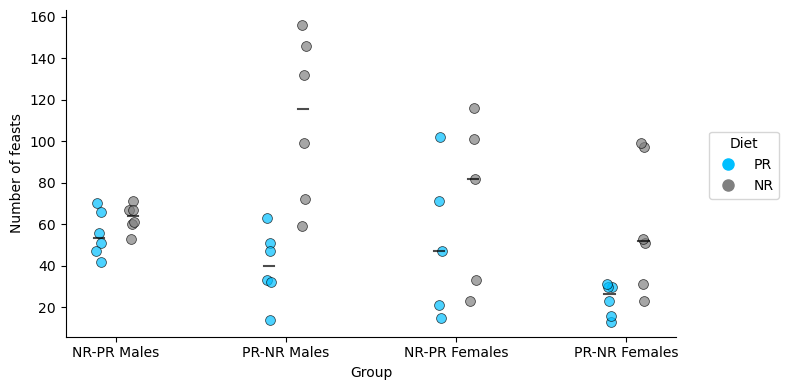

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data extraction using your actual function
nrpr_avg = get_data_fields(mice, ["pr_number_of_mega_meals","nr_number_of_mega_meals"], nrpr_male_selector)
prnr_avg = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], prnr_male_selector)
nrprf_avg = get_data_fields(mice, ["pr_number_of_mega_meals","nr_number_of_mega_meals"], nrpr_female_selector)
prnrf_avg = get_data_fields(mice, ["pr_number_of_mega_meals","nr_number_of_mega_meals"], prnr_female_selector)

# Combine all data for easier plotting
data = [nrpr_avg[0], nrpr_avg[1], prnr_avg[0], prnr_avg[1],
        nrprf_avg[0], nrprf_avg[1], prnrf_avg[0], prnrf_avg[1]]

group_labels = ["NR-PR Males (PR)", "NR-PR Males (NR)", "PR-NR Males (PR)", "PR-NR Males (NR)",
                "NR-PR Females (PR)", "NR-PR Females (NR)", "PR-NR Females (PR)", "PR-NR Females (NR)"]

colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.1, "NR": 0.1}  # Reduced offset for compactness
group_mapping = {
    "NR-PR Males (PR)": ("NR-PR Males", "PR"),
    "NR-PR Males (NR)": ("NR-PR Males", "NR"),
    "PR-NR Males (PR)": ("PR-NR Males", "PR"),
    "PR-NR Males (NR)": ("PR-NR Males", "NR"),
    "NR-PR Females (PR)": ("NR-PR Females", "PR"),
    "NR-PR Females (NR)": ("NR-PR Females", "NR"),
    "PR-NR Females (PR)": ("PR-NR Females", "PR"),
    "PR-NR Females (NR)": ("PR-NR Females", "NR")
}

group_positions = {
    "NR-PR Males": 0,
    "PR-NR Males": 1,
    "NR-PR Females": 2,
    "PR-NR Females": 3
}

# Create a figure and axis with smaller size for compactness
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the scatter plot with reduced jitter and smaller markers
jitter_strength = 0.02  # Reduced jitter for more compact spacing
for i, group_label in enumerate(group_labels):
    group, diet = group_mapping[group_label]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(data[i]))
    x_positions = [group_positions[group] + offset[diet] + jitter_val for jitter_val in jitter]
    sns.scatterplot(x=x_positions, y=data[i], color=colors[diet], s=50, alpha=0.7, edgecolor="black")  # Smaller markers

# Add median lines with slight adjustments for compactness
for group in ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"]:
    for diet in ["PR", "NR"]:
        relevant_data = []
        for group_label in group_labels:
            mapped_group, mapped_diet = group_mapping[group_label]
            if mapped_group == group and mapped_diet == diet:
                relevant_data.extend(data[group_labels.index(group_label)])
        median_value = np.median(relevant_data)
        x_val = group_positions[group] + offset[diet]
        ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize the legend by manually adding it
custom_lines = [plt.Line2D([0], [0], color=colors["PR"], marker='o', linestyle='', markersize=8, label='PR'),
                plt.Line2D([0], [0], color=colors["NR"], marker='o', linestyle='', markersize=8, label='NR')]
plt.legend(handles=custom_lines, title="Diet", loc="upper right", frameon=True, borderaxespad=-3, bbox_to_anchor=(1.1, 0.5))

# Customize the plot aesthetics with tighter spacing
plt.xticks([group_positions["NR-PR Males"], group_positions["PR-NR Males"],
            group_positions["NR-PR Females"], group_positions["PR-NR Females"]],
           ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Number of feasts")

# Remove the background grid lines and spines
plt.grid(False)
sns.despine()

plt.tight_layout()  # Adjust layout to fit labels
plt.show()

# Save the figure if needed
# fig.savefig("pellets_scatter_plot_compact.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


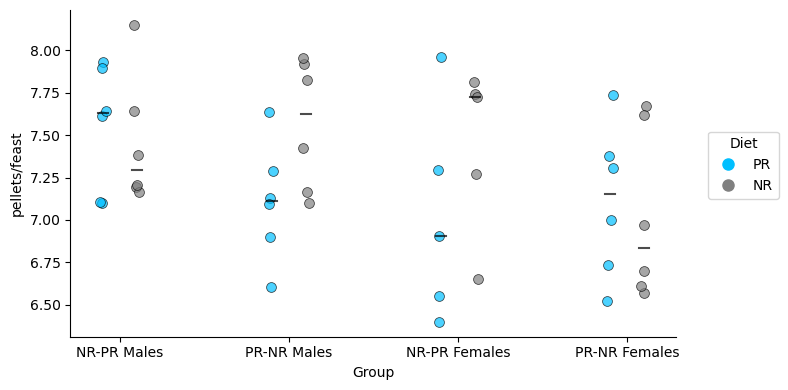

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data extraction using your actual function
nrpr_avg = get_data_fields(mice, ["pr_mega_meal_size","nr_mega_meal_size"], nrpr_male_selector)
prnr_avg = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], prnr_male_selector)
nrprf_avg = get_data_fields(mice, ["pr_mega_meal_size","nr_mega_meal_size"], nrpr_female_selector)
prnrf_avg = get_data_fields(mice, ["pr_mega_meal_size","nr_mega_meal_size"], prnr_female_selector)

# Combine all data for easier plotting
data = [nrpr_avg[0], nrpr_avg[1], prnr_avg[0], prnr_avg[1],
        nrprf_avg[0], nrprf_avg[1], prnrf_avg[0], prnrf_avg[1]]

group_labels = ["NR-PR Males (PR)", "NR-PR Males (NR)", "PR-NR Males (PR)", "PR-NR Males (NR)",
                "NR-PR Females (PR)", "NR-PR Females (NR)", "PR-NR Females (PR)", "PR-NR Females (NR)"]

colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.1, "NR": 0.1}  # Reduced offset for compactness
group_mapping = {
    "NR-PR Males (PR)": ("NR-PR Males", "PR"),
    "NR-PR Males (NR)": ("NR-PR Males", "NR"),
    "PR-NR Males (PR)": ("PR-NR Males", "PR"),
    "PR-NR Males (NR)": ("PR-NR Males", "NR"),
    "NR-PR Females (PR)": ("NR-PR Females", "PR"),
    "NR-PR Females (NR)": ("NR-PR Females", "NR"),
    "PR-NR Females (PR)": ("PR-NR Females", "PR"),
    "PR-NR Females (NR)": ("PR-NR Females", "NR")
}

group_positions = {
    "NR-PR Males": 0,
    "PR-NR Males": 1,
    "NR-PR Females": 2,
    "PR-NR Females": 3
}

# Create a figure and axis with smaller size for compactness
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the scatter plot with reduced jitter and smaller markers
jitter_strength = 0.02  # Reduced jitter for more compact spacing
for i, group_label in enumerate(group_labels):
    group, diet = group_mapping[group_label]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(data[i]))
    x_positions = [group_positions[group] + offset[diet] + jitter_val for jitter_val in jitter]
    sns.scatterplot(x=x_positions, y=data[i], color=colors[diet], s=50, alpha=0.7, edgecolor="black")  # Smaller markers

# Add median lines with slight adjustments for compactness
for group in ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"]:
    for diet in ["PR", "NR"]:
        relevant_data = []
        for group_label in group_labels:
            mapped_group, mapped_diet = group_mapping[group_label]
            if mapped_group == group and mapped_diet == diet:
                relevant_data.extend(data[group_labels.index(group_label)])
        median_value = np.median(relevant_data)
        x_val = group_positions[group] + offset[diet]
        ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize the legend by manually adding it
custom_lines = [plt.Line2D([0], [0], color=colors["PR"], marker='o', linestyle='', markersize=8, label='PR'),
                plt.Line2D([0], [0], color=colors["NR"], marker='o', linestyle='', markersize=8, label='NR')]
plt.legend(handles=custom_lines, title="Diet", loc="upper right", frameon=True, borderaxespad=-3, bbox_to_anchor=(1.1, 0.5))

# Customize the plot aesthetics with tighter spacing
plt.xticks([group_positions["NR-PR Males"], group_positions["PR-NR Males"],
            group_positions["NR-PR Females"], group_positions["PR-NR Females"]],
           ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("pellets/feast")

# Remove the background grid lines and spines
plt.grid(False)
sns.despine()

plt.tight_layout()  # Adjust layout to fit labels
plt.show()

# Save the figure if needed
# fig.savefig("pellets_scatter_plot_compact.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


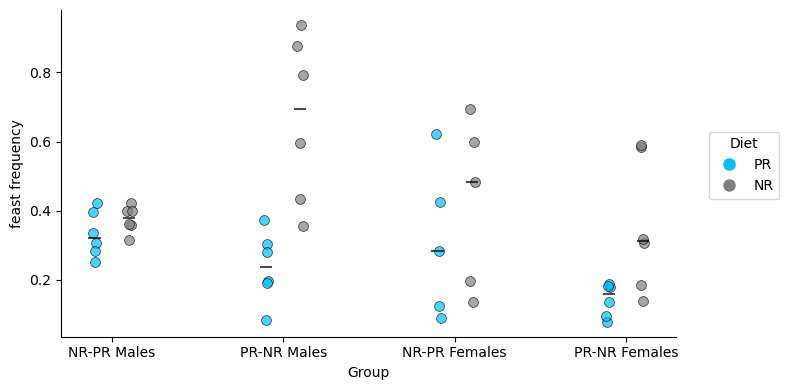

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data extraction using your actual function
nrpr_avg = get_data_fields(mice, ["pr_mega_meal_frequency","nr_mega_meal_frequency"], nrpr_male_selector)
prnr_avg = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], prnr_male_selector)
nrprf_avg = get_data_fields(mice, ["pr_mega_meal_frequency","nr_mega_meal_frequency"], nrpr_female_selector)
prnrf_avg = get_data_fields(mice, ["pr_mega_meal_frequency","nr_mega_meal_frequency"], prnr_female_selector)

# Combine all data for easier plotting
data = [nrpr_avg[0], nrpr_avg[1], prnr_avg[0], prnr_avg[1],
        nrprf_avg[0], nrprf_avg[1], prnrf_avg[0], prnrf_avg[1]]

group_labels = ["NR-PR Males (PR)", "NR-PR Males (NR)", "PR-NR Males (PR)", "PR-NR Males (NR)",
                "NR-PR Females (PR)", "NR-PR Females (NR)", "PR-NR Females (PR)", "PR-NR Females (NR)"]

colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.1, "NR": 0.1}  # Reduced offset for compactness
group_mapping = {
    "NR-PR Males (PR)": ("NR-PR Males", "PR"),
    "NR-PR Males (NR)": ("NR-PR Males", "NR"),
    "PR-NR Males (PR)": ("PR-NR Males", "PR"),
    "PR-NR Males (NR)": ("PR-NR Males", "NR"),
    "NR-PR Females (PR)": ("NR-PR Females", "PR"),
    "NR-PR Females (NR)": ("NR-PR Females", "NR"),
    "PR-NR Females (PR)": ("PR-NR Females", "PR"),
    "PR-NR Females (NR)": ("PR-NR Females", "NR")
}

group_positions = {
    "NR-PR Males": 0,
    "PR-NR Males": 1,
    "NR-PR Females": 2,
    "PR-NR Females": 3
}

# Create a figure and axis with smaller size for compactness
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the scatter plot with reduced jitter and smaller markers
jitter_strength = 0.02  # Reduced jitter for more compact spacing
for i, group_label in enumerate(group_labels):
    group, diet = group_mapping[group_label]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(data[i]))
    x_positions = [group_positions[group] + offset[diet] + jitter_val for jitter_val in jitter]
    sns.scatterplot(x=x_positions, y=data[i], color=colors[diet], s=50, alpha=0.7, edgecolor="black")  # Smaller markers

# Add median lines with slight adjustments for compactness
for group in ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"]:
    for diet in ["PR", "NR"]:
        relevant_data = []
        for group_label in group_labels:
            mapped_group, mapped_diet = group_mapping[group_label]
            if mapped_group == group and mapped_diet == diet:
                relevant_data.extend(data[group_labels.index(group_label)])
        median_value = np.median(relevant_data)
        x_val = group_positions[group] + offset[diet]
        ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize the legend by manually adding it
custom_lines = [plt.Line2D([0], [0], color=colors["PR"], marker='o', linestyle='', markersize=8, label='PR'),
                plt.Line2D([0], [0], color=colors["NR"], marker='o', linestyle='', markersize=8, label='NR')]
plt.legend(handles=custom_lines, title="Diet", loc="upper right", frameon=True, borderaxespad=-3, bbox_to_anchor=(1.1, 0.5))

# Customize the plot aesthetics with tighter spacing
plt.xticks([group_positions["NR-PR Males"], group_positions["PR-NR Males"],
            group_positions["NR-PR Females"], group_positions["PR-NR Females"]],
           ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("feast frequency")

# Remove the background grid lines and spines
plt.grid(False)
sns.despine()

plt.tight_layout()  # Adjust layout to fit labels
plt.show()

# Save the figure if needed
# fig.savefig("pellets_scatter_plot_compact.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


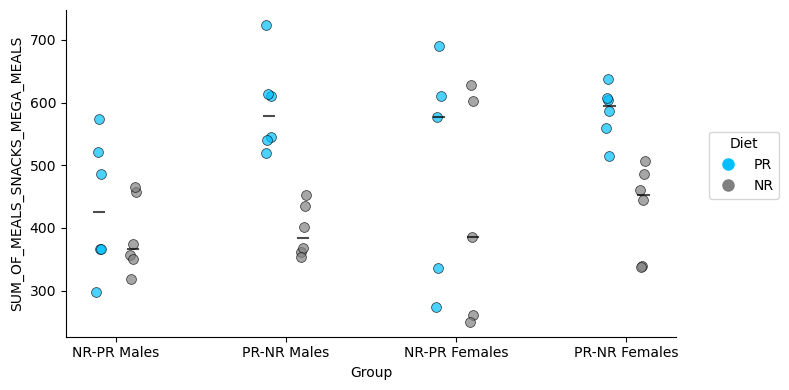

In [28]:
# Data extraction including meals, snacks, and mega_meals
nrpr_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], nrpr_male_selector)
prnr_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], prnr_male_selector)
nrprf_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], nrpr_female_selector)
prnrf_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], prnr_female_selector)

nrpr_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], nrpr_male_selector)
prnr_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], prnr_male_selector)
nrprf_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], nrpr_female_selector)
prnrf_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], prnr_female_selector)

nrpr_mega = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], nrpr_male_selector)
prnr_mega = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], prnr_male_selector)
nrprf_mega = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], nrpr_female_selector)
prnrf_mega = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], prnr_female_selector)

# Sum meals, snacks, and mega_meals
nrpr_sum = [np.add(nrpr_meals[0], np.add(nrpr_snacks[0], nrpr_mega[0])), 
            np.add(nrpr_meals[1], np.add(nrpr_snacks[1], nrpr_mega[1]))]
prnr_sum = [np.add(prnr_meals[0], np.add(prnr_snacks[0], prnr_mega[0])),
            np.add(prnr_meals[1], np.add(prnr_snacks[1], prnr_mega[1]))]
nrprf_sum = [np.add(nrprf_meals[0], np.add(nrprf_snacks[0], nrprf_mega[0])),
             np.add(nrprf_meals[1], np.add(nrprf_snacks[1], nrprf_mega[1]))]
prnrf_sum = [np.add(prnrf_meals[0], np.add(prnrf_snacks[0], prnrf_mega[0])),
             np.add(prnrf_meals[1], np.add(prnrf_snacks[1], prnrf_mega[1]))]


# Combine all summed data for easier plotting
data = [nrpr_sum[0], nrpr_sum[1], prnr_sum[0], prnr_sum[1],
        nrprf_sum[0], nrprf_sum[1], prnrf_sum[0], prnrf_sum[1]]


# Create a figure and axis with smaller size for compactness
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the scatter plot with reduced jitter and smaller markers for summed values
for i, group_label in enumerate(group_labels):
    group, diet = group_mapping[group_label]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(data[i]))
    x_positions = [group_positions[group] + offset[diet] + jitter_val for jitter_val in jitter]
    sns.scatterplot(x=x_positions, y=data[i], color=colors[diet], s=50, alpha=0.7, edgecolor="black")  # Smaller markers

# Add median lines with slight adjustments for compactness
for group in ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"]:
    for diet in ["PR", "NR"]:
        relevant_data = []
        for group_label in group_labels:
            mapped_group, mapped_diet = group_mapping[group_label]
            if mapped_group == group and mapped_diet == diet:
                relevant_data.extend(data[group_labels.index(group_label)])
        median_value = np.median(relevant_data)
        x_val = group_positions[group] + offset[diet]
        ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize the legend
plt.legend(handles=custom_lines, title="Diet", loc="upper right", frameon=True, borderaxespad=-3, bbox_to_anchor=(1.1, 0.5))

# Customize the plot aesthetics with tighter spacing
plt.xticks([group_positions["NR-PR Males"], group_positions["PR-NR Males"],
            group_positions["NR-PR Females"], group_positions["PR-NR Females"]],
           ["NR-PR Males", "PR-NR Males", "NR-PR Females", "PR-NR Females"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("SUM_OF_MEALS_SNACKS_MEGA_MEALS")

# Remove the background grid lines and spines
plt.grid(False)
sns.despine()

plt.tight_layout()  # Adjust layout to fit labels
plt.show()


## <font color = "cornflowerblue">Cell below, measuring IMI and IPI and saving the files </font>

In [1]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes
def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list

# Function to get meal, snack, and mega meal metrics, including mega_meal_frequency and mega_meal_size
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0, [], [])

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    IMIs = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:  # Make sure we are within the 7-day boundary
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 5:
                meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 6:
                mega_meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            IMIs.append(ipi)  # Store IMI as a list of timestamps
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        day_index = int(current_event[0] // 24)
        hour = int(current_event[0]) % 24
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 5:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 6:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)  # Add the number of mega meals

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals, IPIs, IMIs)


# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Load the metafile and process the data
metafile = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

        # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"],
        mice[key]["grain_ipi"],       # IPI for grain phase
        mice[key]["grain_imi"]        # IMI for grain phase
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"],
        mice[key]["pr_ipi"],          # IPI for PR phase
        mice[key]["pr_imi"]           # IMI for PR phase
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"],
        mice[key]["nr_ipi"],          # IPI for NR phase
        mice[key]["nr_imi"]           # IMI for NR phase
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)

# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])
    print("  IPI for Grain phase:", mice[key]["grain_ipi"])
    print("  IMI for Grain phase:", mice[key]["grain_imi"])
    print("  IPI for PR phase:", mice[key]["pr_ipi"])
    print("  IMI for PR phase:", mice[key]["pr_imi"])
    print("  IPI for NR phase:", mice[key]["nr_ipi"])
    print("  IMI for NR phase:", mice[key]["nr_imi"])



Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [47, 30, 28, 37, 33, 36, 27, 30, 34, 25, 14, 24, 24, 21, 20, 11, 11]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 3, 2, 1, 0, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 0, 0], [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1], [0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 3, 1, 0, 1, 0, 0, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 0.7914710335259267
  Mega Meals Size: 7.916666666666667
  IPI for Grain phase: [2.77777778e-04 5.55555556e-04 2.77777778e-04 2.77777778e-04
 

In [31]:
import csv

# Function to save IMI data to a separate CSV
def save_imi_to_csv(mice_data, output_filename):
    with open(output_filename, mode='w', newline='') as file:
        fieldnames = ['mouse_id', 'sex', 'order', 'grain_imi', 'pr_imi', 'nr_imi']
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        
        # Write the header
        writer.writeheader()
        
        # Write IMI data for each mouse
        for mouse_id, mouse_data in mice_data.items():
            row_data = {
                'mouse_id': mouse_id,
                'sex': mouse_data.get('sex', None),
                'order': mouse_data.get('order', None),
                'grain_imi': ', '.join(map(str, mouse_data.get('grain_imi', []))),  # Convert lists to string
                'pr_imi': ', '.join(map(str, mouse_data.get('pr_imi', []))),
                'nr_imi': ', '.join(map(str, mouse_data.get('nr_imi', [])))
            }
            writer.writerow(row_data)

# Function to save IPI data to a separate CSV
def save_ipi_to_csv(mice_data, output_filename):
    with open(output_filename, mode='w', newline='') as file:
        fieldnames = ['mouse_id', 'sex', 'order', 'grain_ipi', 'pr_ipi', 'nr_ipi']
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        
        # Write the header
        writer.writeheader()
        
        # Write IPI data for each mouse
        for mouse_id, mouse_data in mice_data.items():
            row_data = {
                'mouse_id': mouse_id,
                'sex': mouse_data.get('sex', None),
                'order': mouse_data.get('order', None),
                'grain_ipi': ', '.join(map(str, mouse_data.get('grain_ipi', []))),  # Convert lists to string
                'pr_ipi': ', '.join(map(str, mouse_data.get('pr_ipi', []))),
                'nr_ipi': ', '.join(map(str, mouse_data.get('nr_ipi', [])))
            }
            writer.writerow(row_data)

# Example usage
imi_output_filename = '../results/FIVE/imi_data.csv'
ipi_output_filename = '../results/FIVE/ipi_data.csv'

# Save IMI data
save_imi_to_csv(mice, imi_output_filename)

# Save IPI data
save_ipi_to_csv(mice, ipi_output_filename)


# Back to plotting

6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
['black']


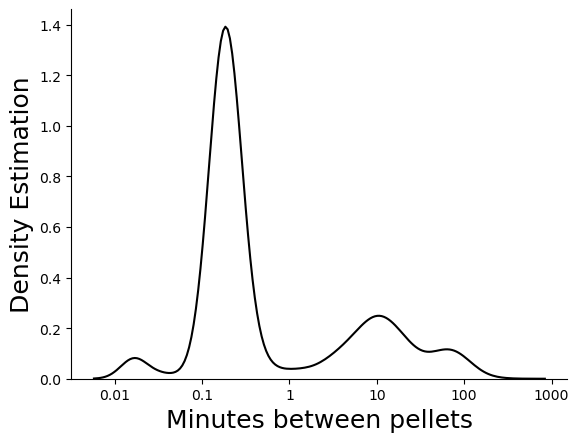

In [52]:
def interpellet_interval_plot(data, ax=[], colors=[], fill=False, labels=[], linestyle="-", **kwargs):
    """
    FED3 Viz: Plot a histogram of interpellet intervals for multiple devices.
    Parameters
    ----------
    FEDs : list of FED3_File objects
        FED3 files (loaded by load.FED3_File)
    kde : bool
        Whether or not to include kernel density estimation, which plots
        probability density (rather than count) and includes a fit line (see
        seaborn.distplot)
    **kwargs :
        ax : matplotlib.axes.Axes
            Axes to plot on, a new Figure and Axes are
            created if not passed
        date_filter : array
            A two-element array of datetimes (start, end) used to filter
            the data
        **kwargs also allows FED3 Viz to pass all settings to all functions.
    Returns
    -------
    fig : matplotlib.figure.Figure
    """

    if ax == []:
        f, ax = plt.subplots()

    if len(colors) != len(data):
        colors = ["grey"] * len(data)
    print(colors)

    if len(labels) != len(data):
        labels = [str(n) for n in range(len(data))]

    for idx, group in enumerate(data):

        y = tp.flatten_list(group)
        y = [np.log10(val*60) for val in y if val > 0]
            
        sns.kdeplot(y, ax=ax,
                    color=colors[idx],
                    fill=fill,
                    label=labels[idx],
                    linestyle=linestyle)

    ax.set_ylabel('Density Estimation',fontsize = 18)
    ax.set_xlabel('Minutes between pellets',fontsize = 18)

    ax.set_xticks(range(-2,4))
    ax.set_xticklabels([10**num for num in range(-2,4)])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}

IPIs_m_nrpr_gr = get_data_fields(mice, ["grain_ipi"], nrpr_male_selector)
IPIs_m_nrpr_nr = get_data_fields(mice, ["nr_ipi"], nrpr_male_selector)

IPIs_m_prnr_pr = get_data_fields(mice, ["grain_ipi"], prnr_male_selector)
IPIs_m_prnr_nr = get_data_fields(mice, ["grain_ipi"], prnr_male_selector)

f, ax = plt.subplots()

interpellet_interval_plot([IPIs_m_nrpr_nr],
                           colors=["black"],
                           linestyle="-",
                           ax=ax)

# interpellet_interval_plot([IPIs_m_nrpr_nr],
#                            colors=["grey"],
#                            linestyle="--",
#                            ax=ax)


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
['grey', 'deepskyblue']
['grey', 'deepskyblue']


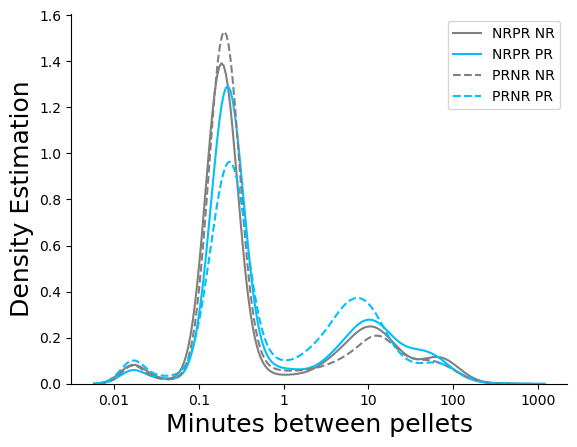

In [53]:
def interpellet_interval_plot(data, ax=[], colors=[], fill=False, labels=[], linestyle="-", **kwargs):
    """
    FED3 Viz: Plot a histogram of interpellet intervals for multiple devices.
    Parameters
    ----------
    FEDs : list of FED3_File objects
        FED3 files (loaded by load.FED3_File)
    kde : bool
        Whether or not to include kernel density estimation, which plots
        probability density (rather than count) and includes a fit line (see
        seaborn.distplot)
    **kwargs :
        ax : matplotlib.axes.Axes
            Axes to plot on, a new Figure and Axes are
            created if not passed
        date_filter : array
            A two-element array of datetimes (start, end) used to filter
            the data
        **kwargs also allows FED3 Viz to pass all settings to all functions.
    Returns
    -------
    fig : matplotlib.figure.Figure
    """

    if ax == []:
        f, ax = plt.subplots()

    if len(colors) != len(data):
        colors = ["grey"] * len(data)
    print(colors)

    if len(labels) != len(data):
        labels = [str(n) for n in range(len(data))]

    for idx, group in enumerate(data):
        y = tp.flatten_list(group)
        y = [np.log10(val * 60) for val in y if val > 0]

        sns.kdeplot(y, ax=ax,
                    color=colors[idx],
                    fill=fill,
                    label=labels[idx],  # Label for legend
                    linestyle=linestyle)

    ax.set_ylabel('Density Estimation', fontsize=18)
    ax.set_xlabel('Minutes between pellets', fontsize=18)

    ax.set_xticks(range(-2, 4))
    ax.set_xticklabels([10**num for num in range(-2, 4)])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Add the legend
    ax.legend()

nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}

IPIs_m_nrpr_pr = get_data_fields(mice, ["pr_ipi"], nrpr_male_selector)
IPIs_m_nrpr_nr = get_data_fields(mice, ["nr_ipi"], nrpr_male_selector)

IPIs_m_prnr_pr = get_data_fields(mice, ["pr_ipi"], prnr_male_selector)
IPIs_m_prnr_nr = get_data_fields(mice, ["nr_ipi"], prnr_male_selector)

f, ax = plt.subplots()

# First plot with solid lines
interpellet_interval_plot([IPIs_m_nrpr_nr, IPIs_m_nrpr_pr],
                          colors=["grey", "deepskyblue"],
                          linestyle="-",
                          labels=["NRPR NR", "NRPR PR"],  # Add labels for legend
                          ax=ax)

# Second plot with dashed lines
interpellet_interval_plot([IPIs_m_prnr_nr, IPIs_m_prnr_pr],
                          colors=["grey", "deepskyblue"],
                          linestyle="--",
                          labels=["PRNR NR", "PRNR PR"],  # Add labels for legend
                          ax=ax)

plt.show()


6 items in output dictionary


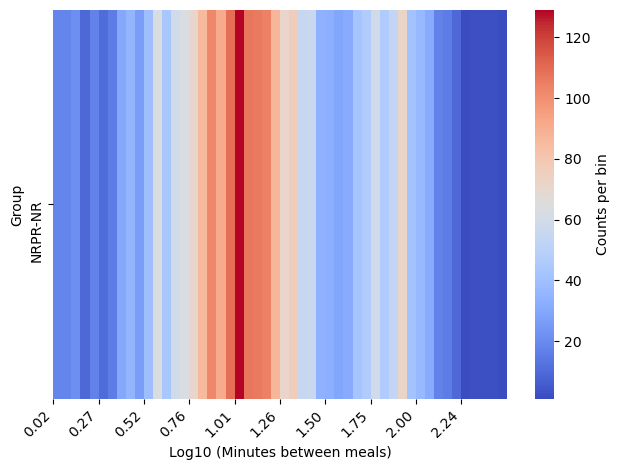

In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def intermeal_interval_heatmap(data, ax=None, label="NRPR-NR", bins=50, tick_step=5, **kwargs):
    """
    FED3 Viz: Create a heatmap of intermeal intervals for a single group, with X-axis binned.

    Parameters
    ----------
    data : list
        List contains IMI data for a group (e.g., NRPR-NR).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    label : str, optional
        Label for the dataset (group), by default "NRPR-NR"
    bins : int, optional
        Number of bins for grouping IMIs on the X-axis, by default 50.
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 5.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """

    if ax is None:
        fig, ax = plt.subplots()

    # Flatten and log-transform the data
    flattened = tp.flatten_list(data)
    log_transformed = [np.log10(val * 60) for val in flattened if val > 0]
    
    # Bin the data into specified number of bins
    hist, bin_edges = np.histogram(log_transformed, bins=bins)

    # Create a 2D array from the histogram data
    data_matrix = np.array([hist])  # Single-row matrix

    # Create the heatmap
    sns.heatmap(data_matrix, ax=ax, cmap="coolwarm", cbar_kws={'label': 'Counts per bin'}, **kwargs)

    # Set labels
    ax.set_yticks([0.5])
    ax.set_yticklabels([label])
    ax.set_xlabel('Log10 (Minutes between meals)')
    ax.set_ylabel('Group')

    # Set X-axis labels as bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    # Only show every nth tick to avoid label overlap
    ax.set_xticks(np.arange(0, len(bin_centers), tick_step))
    ax.set_xticklabels([f"{center:.2f}" for center in bin_centers[::tick_step]], rotation=45, ha='right')

    # Adjust the plot to prevent label overlapping
    plt.tight_layout()

    return ax


# Fetching the data for the NRPR_NR group for IMI
nrpr_male_selector = {"order": 1, "sex": "M"}
IMIs_m_nrpr_nr = get_data_fields(mice, ["nr_imi"], nrpr_male_selector)

# Plotting the heatmap for NRPR_NR IMI
fig, ax = plt.subplots()
intermeal_interval_heatmap(IMIs_m_nrpr_nr, ax=ax, label="NRPR-NR", bins=50, tick_step=5)
plt.show()


6 items in output dictionary
6 items in output dictionary


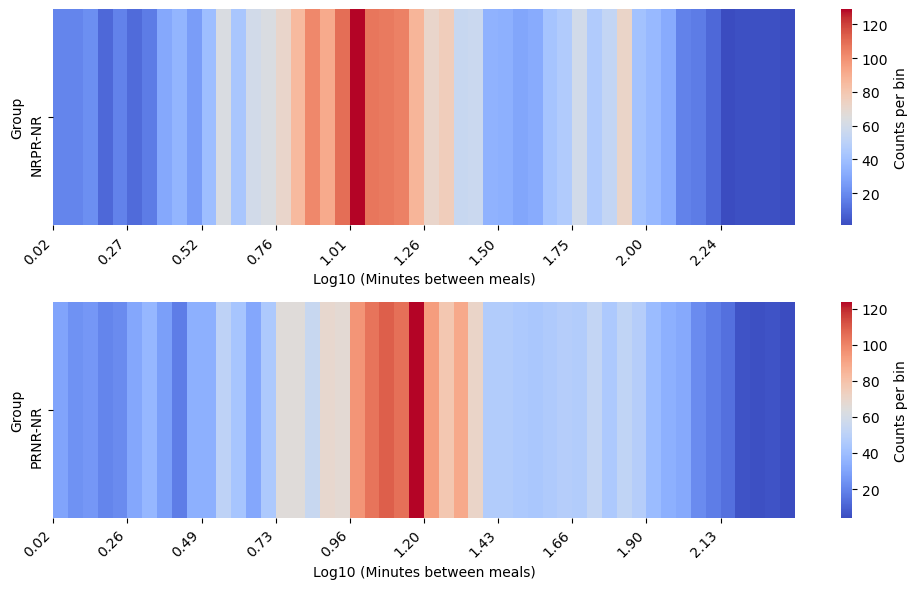

In [55]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def intermeal_interval_heatmap(data, ax=None, label="NRPR-NR", bins=50, tick_step=5, **kwargs):
    """
    FED3 Viz: Create a heatmap of intermeal intervals for a single group, with X-axis binned.

    Parameters
    ----------
    data : list
        List contains IMI data for a group (e.g., NRPR-NR).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    label : str, optional
        Label for the dataset (group), by default "NRPR-NR"
    bins : int, optional
        Number of bins for grouping IMIs on the X-axis, by default 50.
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 5.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """

    if ax is None:
        fig, ax = plt.subplots()

    # Flatten and log-transform the data
    flattened = tp.flatten_list(data)
    log_transformed = [np.log10(val * 60) for val in flattened if val > 0]
    
    # Bin the data into specified number of bins
    hist, bin_edges = np.histogram(log_transformed, bins=bins)

    # Create a 2D array from the histogram data
    data_matrix = np.array([hist])  # Single-row matrix

    # Create the heatmap
    sns.heatmap(data_matrix, ax=ax, cmap="coolwarm", cbar_kws={'label': 'Counts per bin'}, **kwargs)

    # Set labels
    ax.set_yticks([0.5])
    ax.set_yticklabels([label])
    ax.set_xlabel('Log10 (Minutes between meals)')
    ax.set_ylabel('Group')

    # Set X-axis labels as bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    # Only show every nth tick to avoid label overlap
    ax.set_xticks(np.arange(0, len(bin_centers), tick_step))
    ax.set_xticklabels([f"{center:.2f}" for center in bin_centers[::tick_step]], rotation=45, ha='right')

    # Adjust the plot to prevent label overlapping
    plt.tight_layout()

    return ax


# Fetching the data for the NRPR_NR group and the PRNR_NR group for IMI
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}

IMIs_m_nrpr_nr = get_data_fields(mice, ["nr_imi"], nrpr_male_selector)
IMIs_m_prnr_nr = get_data_fields(mice, ["nr_imi"], prnr_male_selector)

# Creating subplots for both groups
fig, axs = plt.subplots(2, 1, figsize=(10, 6))

# Plotting the heatmap for NRPR_NR IMI
intermeal_interval_heatmap(IMIs_m_nrpr_nr, ax=axs[0], label="NRPR-NR", bins=50, tick_step=5)

# Plotting the heatmap for PRNR_NR IMI
intermeal_interval_heatmap(IMIs_m_prnr_nr, ax=axs[1], label="PRNR-NR", bins=50, tick_step=5)

plt.show()


6 items in output dictionary
6 items in output dictionary


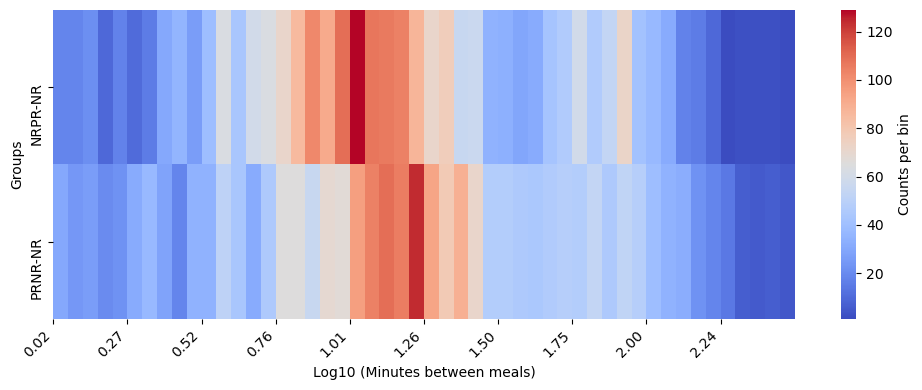

In [56]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def intermeal_interval_heatmap(data1, data2, ax=None, labels=["NRPR-NR", "PRNR-NR"], bins=50, tick_step=5, **kwargs):
    """
    FED3 Viz: Create a heatmap of intermeal intervals for two groups, with X-axis binned.

    Parameters
    ----------
    data1 : list
        List contains IMI data for group 1 (e.g., NRPR-NR).
    data2 : list
        List contains IMI data for group 2 (e.g., PRNR-NR).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["NRPR-NR", "PRNR-NR"].
    bins : int, optional
        Number of bins for grouping IMIs on the X-axis, by default 50.
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 5.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """

    if ax is None:
        fig, ax = plt.subplots()

    # Flatten and log-transform the data for both groups
    flattened1 = tp.flatten_list(data1)
    log_transformed1 = [np.log10(val * 60) for val in flattened1 if val > 0]

    flattened2 = tp.flatten_list(data2)
    log_transformed2 = [np.log10(val * 60) for val in flattened2 if val > 0]
    
    # Bin the data for both groups
    hist1, bin_edges = np.histogram(log_transformed1, bins=bins)
    hist2, _ = np.histogram(log_transformed2, bins=bins)

    # Create a 2D array from the histogram data, stacking the two groups
    data_matrix = np.array([hist1, hist2])

    # Create the heatmap
    sns.heatmap(data_matrix, ax=ax, cmap="coolwarm", cbar_kws={'label': 'Counts per bin'}, **kwargs)

    # Set labels
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(labels)
    ax.set_xlabel('Log10 (Minutes between meals)')
    ax.set_ylabel('Groups')

    # Set X-axis labels as bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    # Only show every nth tick to avoid label overlap
    ax.set_xticks(np.arange(0, len(bin_centers), tick_step))
    ax.set_xticklabels([f"{center:.2f}" for center in bin_centers[::tick_step]], rotation=45, ha='right')

    # Adjust the plot to prevent label overlapping
    plt.tight_layout()

    return ax

# Fetching the data for the NRPR_NR group and the PRNR_NR group for IMI
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}

IMIs_m_nrpr_nr = get_data_fields(mice, ["nr_imi"], nrpr_male_selector)
IMIs_m_prnr_nr = get_data_fields(mice, ["nr_imi"], prnr_male_selector)

# Plotting the heatmap with both groups on the same plot
fig, ax = plt.subplots(figsize=(10, 4))

intermeal_interval_heatmap(IMIs_m_nrpr_nr, IMIs_m_prnr_nr, ax=ax, labels=["NRPR-NR", "PRNR-NR"], bins=50, tick_step=5)

plt.show()


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


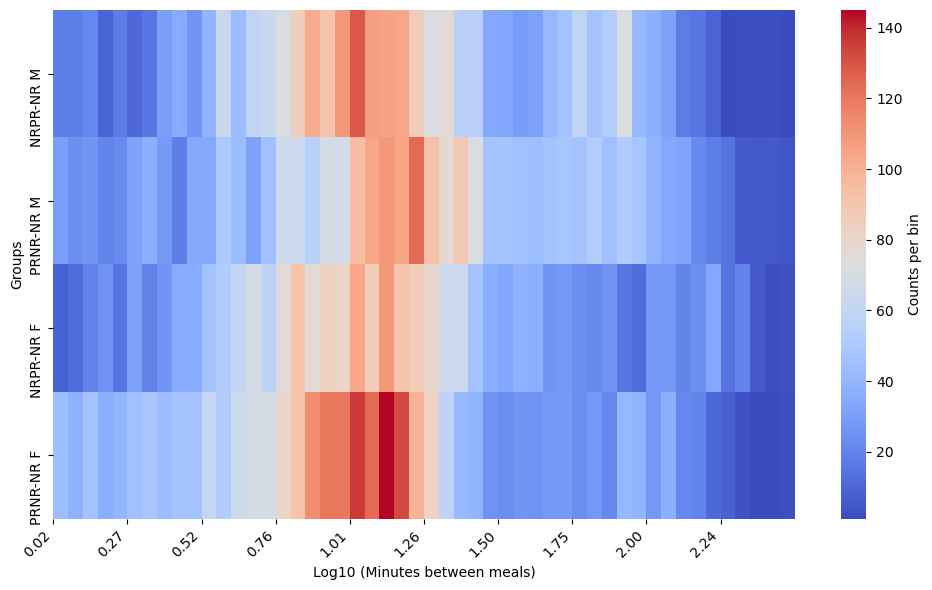

In [57]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def intermeal_interval_heatmap(data1, data2, data3, data4, ax=None, labels=["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"], bins=50, tick_step=5, **kwargs):
    """
    FED3 Viz: Create a heatmap of intermeal intervals for four groups, with X-axis binned.

    Parameters
    ----------
    data1 : list
        List contains IMI data for group 1 (e.g., NRPR-NR M).
    data2 : list
        List contains IMI data for group 2 (e.g., PRNR-NR M).
    data3 : list
        List contains IMI data for group 3 (e.g., NRPR-NR F).
    data4 : list
        List contains IMI data for group 4 (e.g., PRNR-NR F).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"].
    bins : int, optional
        Number of bins for grouping IMIs on the X-axis, by default 50.
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 5.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """

    if ax is None:
        fig, ax = plt.subplots()

    # Flatten and log-transform the data for all groups
    flattened1 = tp.flatten_list(data1)
    log_transformed1 = [np.log10(val * 60) for val in flattened1 if val > 0]

    flattened2 = tp.flatten_list(data2)
    log_transformed2 = [np.log10(val * 60) for val in flattened2 if val > 0]
    
    flattened3 = tp.flatten_list(data3)
    log_transformed3 = [np.log10(val * 60) for val in flattened3 if val > 0]
    
    flattened4 = tp.flatten_list(data4)
    log_transformed4 = [np.log10(val * 60) for val in flattened4 if val > 0]

    # Bin the data for all groups
    hist1, bin_edges = np.histogram(log_transformed1, bins=bins)
    hist2, _ = np.histogram(log_transformed2, bins=bins)
    hist3, _ = np.histogram(log_transformed3, bins=bins)
    hist4, _ = np.histogram(log_transformed4, bins=bins)

    # Create a 2D array from the histogram data, stacking the four groups
    data_matrix = np.array([hist1, hist2, hist3, hist4])

    # Create the heatmap
    sns.heatmap(data_matrix, ax=ax, cmap="coolwarm", cbar_kws={'label': 'Counts per bin'}, **kwargs)

    # Set labels
    ax.set_yticks([0.5, 1.5, 2.5, 3.5])
    ax.set_yticklabels(labels)
    ax.set_xlabel('Log10 (Minutes between meals)')
    ax.set_ylabel('Groups')

    # Set X-axis labels as bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    # Only show every nth tick to avoid label overlap
    ax.set_xticks(np.arange(0, len(bin_centers), tick_step))
    ax.set_xticklabels([f"{center:.2f}" for center in bin_centers[::tick_step]], rotation=45, ha='right')

    # Adjust the plot to prevent label overlapping
    plt.tight_layout()

    return ax

# Fetching the data for the four groups
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}

IMIs_m_nrpr_nr = get_data_fields(mice, ["nr_imi"], nrpr_male_selector)
IMIs_m_prnr_nr = get_data_fields(mice, ["nr_imi"], prnr_male_selector)
IMIs_f_nrpr_nr = get_data_fields(mice, ["nr_imi"], nrpr_female_selector)
IMIs_f_prnr_nr = get_data_fields(mice, ["nr_imi"], prnr_female_selector)

# Plotting the heatmap with all four groups on the same plot
fig, ax = plt.subplots(figsize=(10, 6))

intermeal_interval_heatmap(IMIs_m_nrpr_nr, IMIs_m_prnr_nr, IMIs_f_nrpr_nr, IMIs_f_prnr_nr, ax=ax, 
                           labels=["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"], 
                           bins=50, tick_step=5)

plt.show()


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary


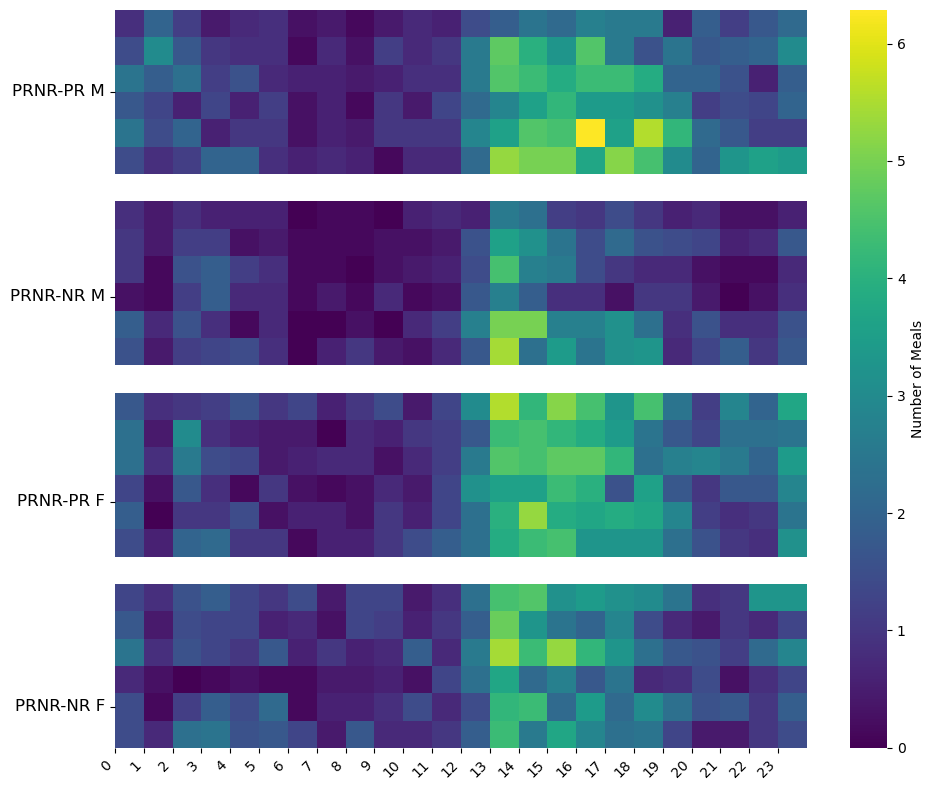

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def hourly_meals_heatmap(data1, data2, data3, data4, ax=None, labels=["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly meals for four groups of male and female mice, averaging across 7 days,
    and ensuring proper label separation.
    
    Parameters
    ----------
    data1 : list
        List contains hourly meals data for group 1 (e.g., NRPR-NR M).
    data2 : list
        List contains hourly meals data for group 2 (e.g., PRNR-NR M).
    data3 : list
        List contains hourly meals data for group 3 (e.g., NRPR-NR F).
    data4 : list
        List contains hourly meals data for group 4 (e.g., PRNR-NR F).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Average across 7 days to get (mice, 24 hours)
    hourly_meals1 = np.mean(np.array(data1), axis=1)  # Expect shape (6, 24) for NRPR-NR M
    hourly_meals2 = np.mean(np.array(data2), axis=1)  # Expect shape (6, 24) for PRNR-NR M
    hourly_meals3 = np.mean(np.array(data3), axis=1)  # Expect shape (5, 24) for NRPR-NR F
    hourly_meals4 = np.mean(np.array(data4), axis=1)  # Expect shape (6, 24) for PRNR-NR F (6 mice)

    # Add padding between the datasets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([hourly_meals1, padding, hourly_meals2, padding, hourly_meals3, padding, hourly_meals4])

    # Create the heatmap
    sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Meals'}, **kwargs)

    # Set Y-tick labels and positions, ensuring separation
    group_lengths = [hourly_meals1.shape[0], hourly_meals2.shape[0], hourly_meals3.shape[0], hourly_meals4.shape[0]]
    y_positions = np.cumsum(group_lengths) - np.array(group_lengths) / 2 + np.arange(len(group_lengths)) * 1.5  # Add 1.5 space between groups
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=12)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')

    # Adjust layout to avoid label overlapping
    plt.tight_layout()

    return ax

# Fetching the hourly meals data for NRPR-NR and PRNR-NR male and female mice
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m_prnr = get_data_fields(mice, ["pr_hourly_meals"], prnr_male_selector)
nr_hourly_meals_m_prnr = get_data_fields(mice, ["nr_hourly_meals"], prnr_male_selector)
pr_hourly_meals_f_prnr = get_data_fields(mice, ["pr_hourly_meals"], prnr_female_selector)
nr_hourly_meals_f_prnr = get_data_fields(mice, ["nr_hourly_meals"], prnr_female_selector)

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(pr_hourly_meals_m_prnr, nr_hourly_meals_m_prnr, 
                     pr_hourly_meals_f_prnr, nr_hourly_meals_f_prnr, 
                     ax=ax, labels=["PRNR-PR M", "PRNR-NR M", "PRNR-PR F", "PRNR-NR F"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
5 items in output dictionary


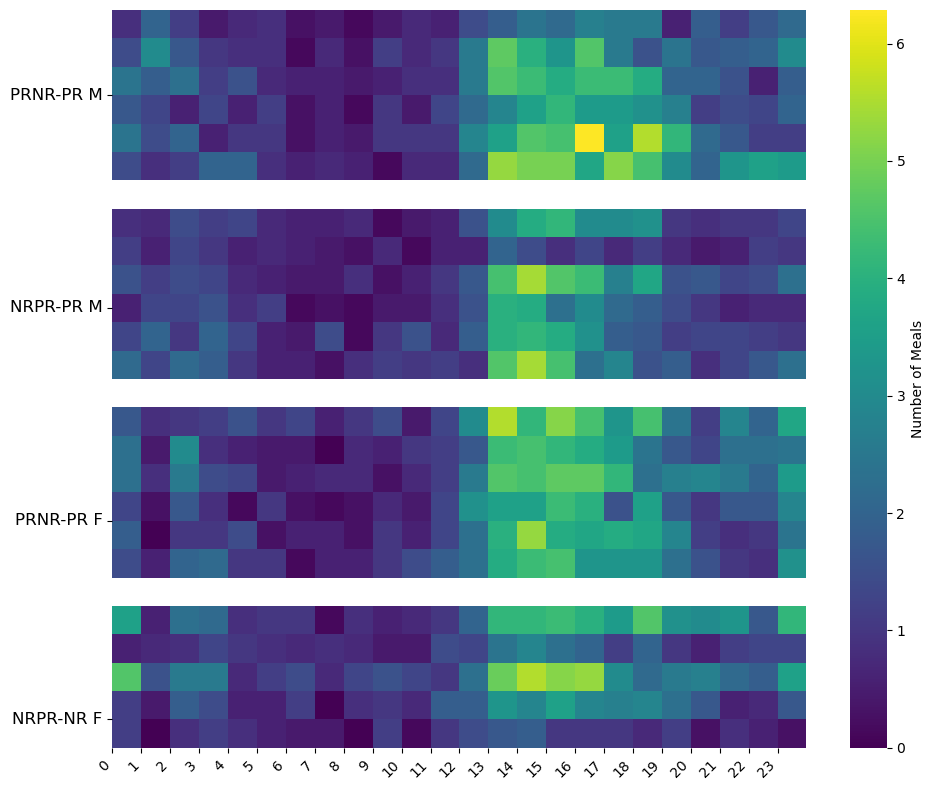

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def hourly_meals_heatmap(data1, data2, data3, data4, ax=None, labels=["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly meals for four groups of male and female mice, averaging across 7 days,
    and ensuring proper label separation.
    
    Parameters
    ----------
    data1 : list
        List contains hourly meals data for group 1 (e.g., NRPR-NR M).
    data2 : list
        List contains hourly meals data for group 2 (e.g., PRNR-NR M).
    data3 : list
        List contains hourly meals data for group 3 (e.g., NRPR-NR F).
    data4 : list
        List contains hourly meals data for group 4 (e.g., PRNR-NR F).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Average across 7 days to get (mice, 24 hours)
    hourly_meals1 = np.mean(np.array(data1), axis=1)  # Expect shape (6, 24) for NRPR-NR M
    hourly_meals2 = np.mean(np.array(data2), axis=1)  # Expect shape (6, 24) for PRNR-NR M
    hourly_meals3 = np.mean(np.array(data3), axis=1)  # Expect shape (5, 24) for NRPR-NR F
    hourly_meals4 = np.mean(np.array(data4), axis=1)  # Expect shape (6, 24) for PRNR-NR F (6 mice)

    # Add padding between the datasets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([hourly_meals1, padding, hourly_meals2, padding, hourly_meals3, padding, hourly_meals4])

    # Create the heatmap
    sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Meals'}, **kwargs)

    # Set Y-tick labels and positions, ensuring separation
    group_lengths = [hourly_meals1.shape[0], hourly_meals2.shape[0], hourly_meals3.shape[0], hourly_meals4.shape[0]]
    y_positions = np.cumsum(group_lengths) - np.array(group_lengths) / 2 + np.arange(len(group_lengths)) * 1.5  # Add 1.5 space between groups
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=12)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')

    # Adjust layout to avoid label overlapping
    plt.tight_layout()

    return ax

# Fetching the hourly meals data for NRPR-NR and PRNR-NR male and female mice
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m_prnr = get_data_fields(mice, ["pr_hourly_meals"], prnr_male_selector)
nr_hourly_meals_m_prnr = get_data_fields(mice, ["pr_hourly_meals"], nrpr_male_selector)
pr_hourly_meals_f_prnr = get_data_fields(mice, ["pr_hourly_meals"], prnr_female_selector)
nr_hourly_meals_f_prnr = get_data_fields(mice, ["pr_hourly_meals"], nrpr_female_selector)

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(pr_hourly_meals_m_prnr, nr_hourly_meals_m_prnr, 
                     pr_hourly_meals_f_prnr, nr_hourly_meals_f_prnr, 
                     ax=ax, labels=["PRNR-PR M", "NRPR-PR M", "PRNR-PR F", "NRPR-NR F"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
5 items in output dictionary


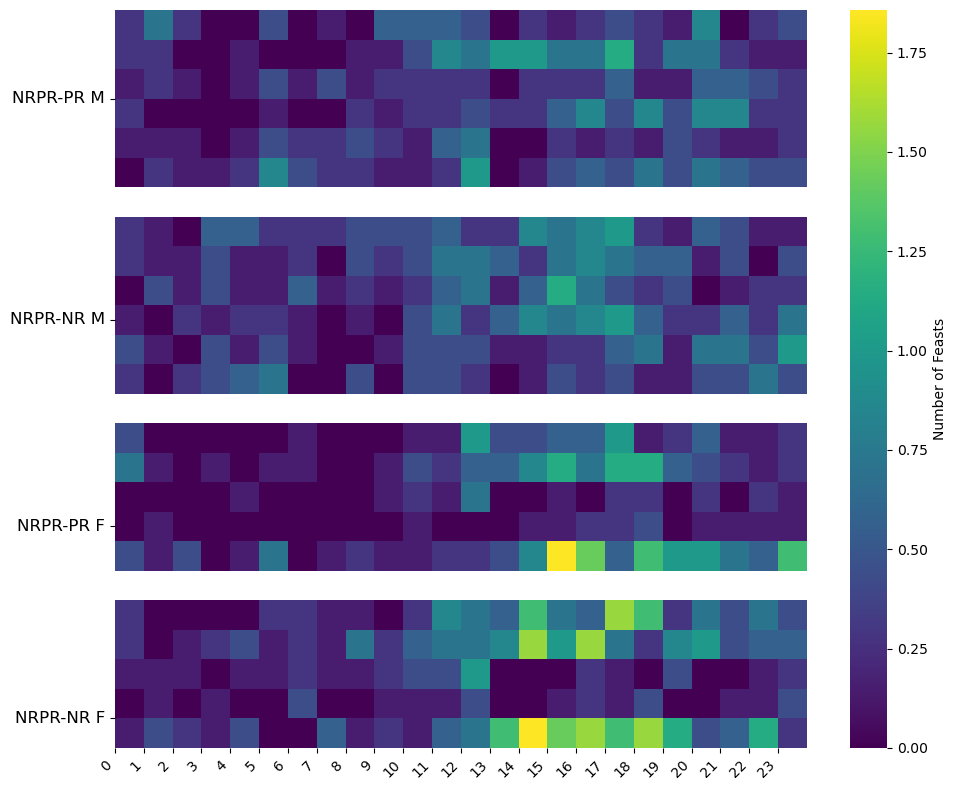

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def hourly_meals_heatmap(data1, data2, data3, data4, ax=None, labels=["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly meals for four groups of male and female mice, averaging across 7 days,
    and ensuring proper label separation.
    
    Parameters
    ----------
    data1 : list
        List contains hourly meals data for group 1 (e.g., NRPR-NR M).
    data2 : list
        List contains hourly meals data for group 2 (e.g., PRNR-NR M).
    data3 : list
        List contains hourly meals data for group 3 (e.g., NRPR-NR F).
    data4 : list
        List contains hourly meals data for group 4 (e.g., PRNR-NR F).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Average across 7 days to get (mice, 24 hours)
    hourly_meals1 = np.mean(np.array(data1), axis=1)  # Expect shape (6, 24)
    hourly_meals2 = np.mean(np.array(data2), axis=1)  # Expect shape (6, 24)
    hourly_meals3 = np.mean(np.array(data3), axis=1)  # Expect shape (5, 24)
    hourly_meals4 = np.mean(np.array(data4), axis=1)  # Expect shape (5, 24)

    # Add padding between the datasets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([hourly_meals1, padding, hourly_meals2, padding, hourly_meals3, padding, hourly_meals4])

    # Create the heatmap
    sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Feasts'}, **kwargs)

    # Set Y-tick labels and positions, ensuring separation
    group_lengths = [hourly_meals1.shape[0], hourly_meals2.shape[0], hourly_meals3.shape[0], hourly_meals4.shape[0]]
    y_positions = np.cumsum(group_lengths) - np.array(group_lengths) / 2 + np.arange(len(group_lengths)) * 1.5  # Add 1.5 space between groups
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=12)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')

    # Adjust layout to avoid label overlapping
    plt.tight_layout()

    return ax

# Fetching the hourly mega meals data for NRPR-NR and PRNR-NR male and female mice
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m_prnr = get_data_fields(mice, ["pr_hourly_mega_meals"], nrpr_male_selector)
nr_hourly_meals_m_prnr = get_data_fields(mice, ["nr_hourly_mega_meals"], nrpr_male_selector)
pr_hourly_meals_f_prnr = get_data_fields(mice, ["pr_hourly_mega_meals"], nrpr_female_selector)
nr_hourly_meals_f_prnr = get_data_fields(mice, ["nr_hourly_mega_meals"], nrpr_female_selector)

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(pr_hourly_meals_m_prnr, nr_hourly_meals_m_prnr, 
                     pr_hourly_meals_f_prnr, nr_hourly_meals_f_prnr, 
                     ax=ax, labels=["NRPR-PR M", "NRPR-NR M", "NRPR-PR F", "NRPR-NR F"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary


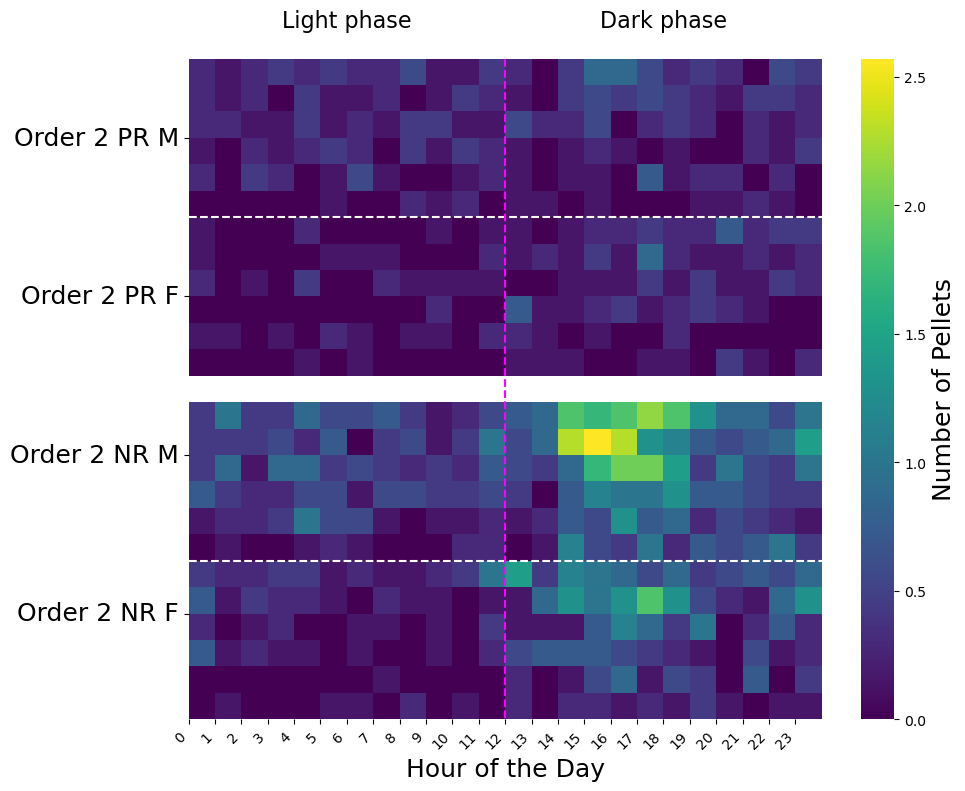

In [26]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Pellets'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 2, "sex": "M"}
nr_male_selector = {"order": 2, "sex": "M"}
pr_female_selector = {"order": 2, "sex": "F"}
nr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_mega_meals"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_mega_meals"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_mega_meals"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_mega_meals"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 2 PR M", "Order 2 PR F", "Order 2 NR M", "Order 2 NR F"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary


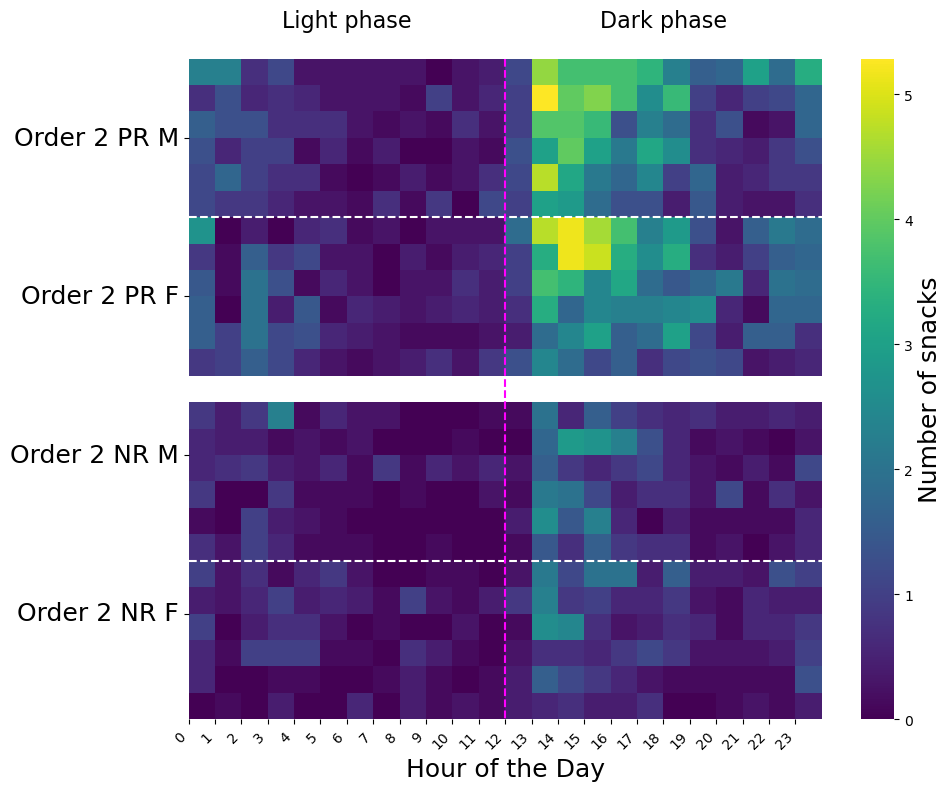

In [28]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of snacks'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 2, "sex": "M"}
nr_male_selector = {"order": 2, "sex": "M"}
pr_female_selector = {"order": 2, "sex": "F"}
nr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_snacks"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_snacks"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_snacks"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_snacks"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 2 PR M", "Order 2 PR F", "Order 2 NR M", "Order 2 NR F"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
5 items in output dictionary


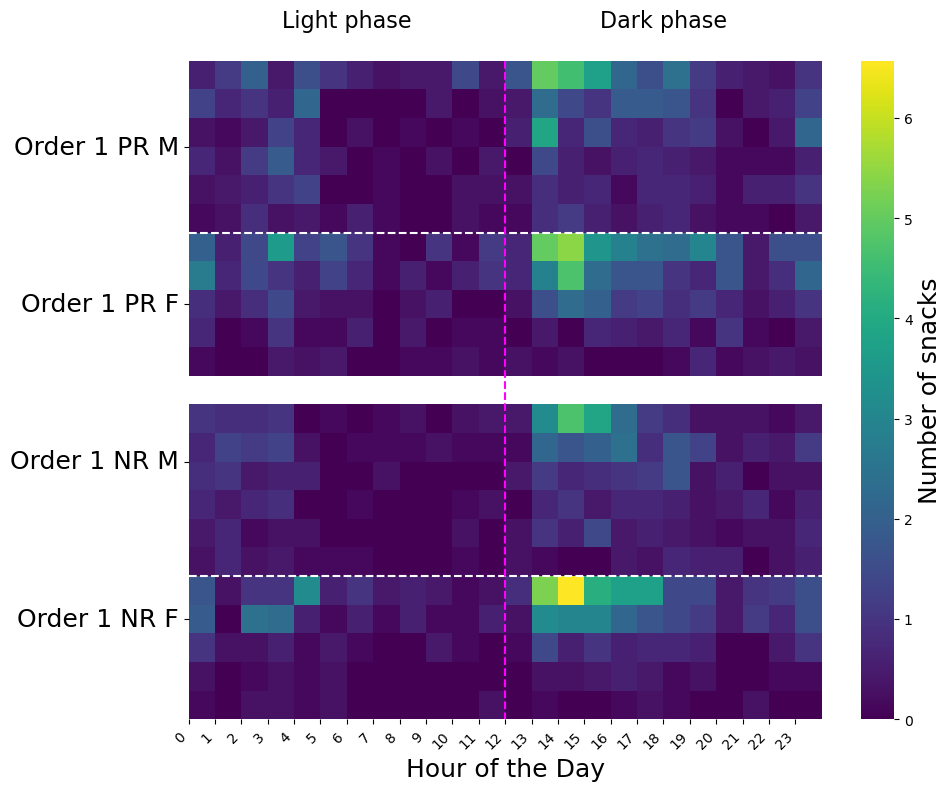

: 

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of snacks'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 1, "sex": "M"}
nr_male_selector = {"order": 1, "sex": "M"}
pr_female_selector = {"order": 1, "sex": "F"}
nr_female_selector = {"order": 1, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_snacks"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_snacks"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_snacks"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_snacks"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
5 items in output dictionary


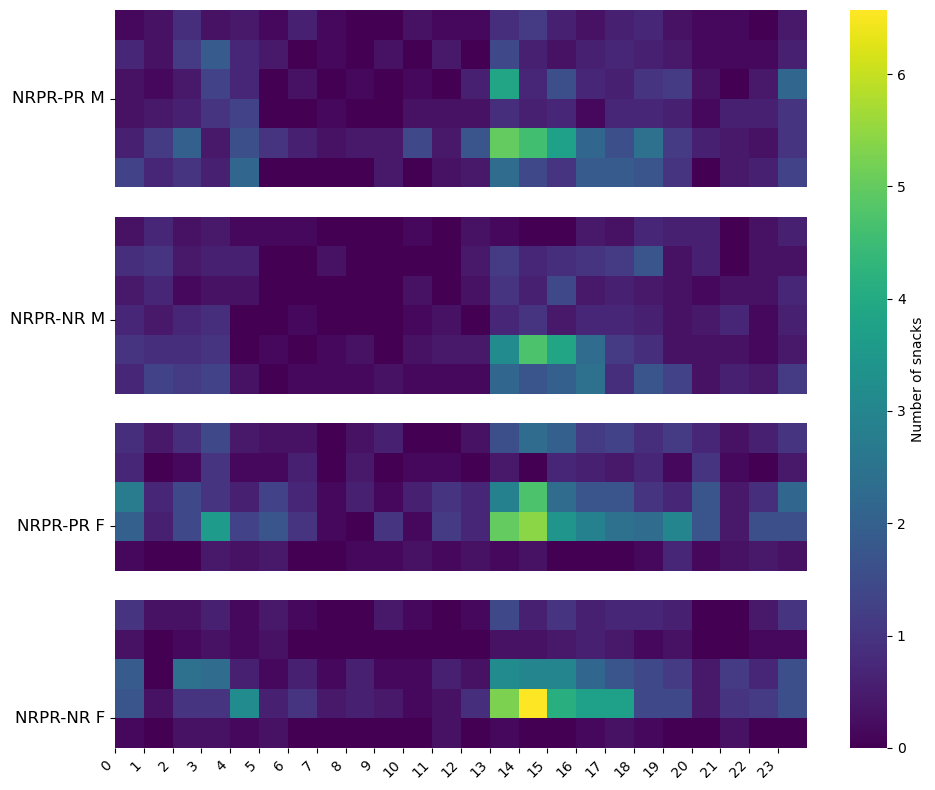

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def hourly_meals_heatmap(data1, data2, data3, data4, ax=None, labels=["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly meals for four groups of male and female mice, averaging across 7 days,
    and ensuring proper label separation.
    
    Parameters
    ----------
    data1 : list
        List contains hourly meals data for group 1 (e.g., NRPR-NR M).
    data2 : list
        List contains hourly meals data for group 2 (e.g., PRNR-NR M).
    data3 : list
        List contains hourly meals data for group 3 (e.g., NRPR-NR F).
    data4 : list
        List contains hourly meals data for group 4 (e.g., PRNR-NR F).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Average across 7 days to get (mice, 24 hours)
    hourly_meals1 = np.mean(np.array(data1), axis=1)  # Expect shape (6, 24)
    hourly_meals2 = np.mean(np.array(data2), axis=1)  # Expect shape (6, 24)
    hourly_meals3 = np.mean(np.array(data3), axis=1)  # Expect shape (5, 24)
    hourly_meals4 = np.mean(np.array(data4), axis=1)  # Expect shape (5, 24)

    # Add padding between the datasets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([hourly_meals1, padding, hourly_meals2, padding, hourly_meals3, padding, hourly_meals4])

    # Create the heatmap
    sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of snacks'}, **kwargs)

    # Set Y-tick labels and positions, ensuring separation
    group_lengths = [hourly_meals1.shape[0], hourly_meals2.shape[0], hourly_meals3.shape[0], hourly_meals4.shape[0]]
    y_positions = np.cumsum(group_lengths) - np.array(group_lengths) / 2 + np.arange(len(group_lengths)) * 1.5  # Add 1.5 space between groups
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=12)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')

    # Adjust layout to avoid label overlapping
    plt.tight_layout()

    return ax

# Fetching the hourly meals data for NRPR-NR and PRNR-NR male and female mice
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m_prnr = get_data_fields(mice, ["pr_hourly_snacks"], nrpr_male_selector)
nr_hourly_meals_m_prnr = get_data_fields(mice, ["nr_hourly_snacks"], nrpr_male_selector)
pr_hourly_meals_f_prnr = get_data_fields(mice, ["pr_hourly_snacks"], nrpr_female_selector)
nr_hourly_meals_f_prnr = get_data_fields(mice, ["nr_hourly_snacks"], nrpr_female_selector)

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(pr_hourly_meals_m_prnr, nr_hourly_meals_m_prnr, 
                     pr_hourly_meals_f_prnr, nr_hourly_meals_f_prnr, 
                     ax=ax, labels=["NRPR-PR M", "NRPR-NR M", "NRPR-PR F", "NRPR-NR F"], tick_step=1)

plt.show()


# HOURLY PELLET INTAKE WAS NOT MEASURED AND SAVED BEFORE, CELL BELOW OPERATES IT

In [2]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes

def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list
# Function to get meal, snack, mega meal metrics, and hourly pellet intake
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0)

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_pellet_intake = [[0]*24 for _ in range(7)]  # New addition to track pellet intake per hour

    for i, ipi in enumerate(IPIs):
        hour = int(pellettimes[i] % 24)
        day_index = int(pellettimes[i] // 24)
        if day_index < 7:
            hourly_pellet_intake[day_index][hour] += 1  # Increment pellet count for the hour

        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                if day_index < 7:
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 5:
                meals.append(current_event)
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 6:
                mega_meals.append(current_event)
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        hour = int(current_event[0] % 24)
        day_index = int(current_event[0] // 24)
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 5:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 6:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, hourly_pellet_intake, meals, snacks, mega_meals, n_mega_meals)



# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Function to calculate inter-pellet intervals (IPI)
def get_interpellet_intervals(pellettimes):
    IPIs = np.diff(pellettimes)
    return IPIs

# Function to calculate intermeal intervals (IMI)
def get_intermeal_interval(pellettimes, meal_threshold=1/60):
    IPIs = np.diff(pellettimes)
    IMIs = [x for x in IPIs if x > meal_threshold]
    average_IMI = np.mean(IMIs) if IMIs else 0  # Handle case with no IMIs
    return average_IMI

# Load the metafile and process the data
metafile = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

    # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        mice[key]["grain_hourly_pellet_intake"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"]  # Store the number of mega meals
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        mice[key]["pr_hourly_pellet_intake"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"]  # Store the number of mega meals
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        mice[key]["nr_hourly_pellet_intake"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"]  # Store the number of mega meals
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)


# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])

Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [47, 30, 28, 37, 33, 36, 27, 30, 34, 25, 14, 24, 24, 21, 20, 11, 11]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 2, 3, 2, 1, 0, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 0, 0], [0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1], [0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 3, 1, 0, 1, 0, 0, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 0.7914710335259267
  Mega Meals Size: 7.916666666666667
Mouse FEDXA02:
  Pellets per day: [304, 214, 194, 154, 153, 204, 211, 203, 226, 214, 

In [7]:
import pandas as pd

# Function to save the data into CSV
def save_hourly_pellet_intake_to_csv(mice_data, filename):
    data_to_save = []
    
    # Loop through each mouse in the dataset
    for mouse_id, mouse_data in mice_data.items():
        for day_index in range(7):  # Loop through each day (0-6)
            for hour in range(24):  # Loop through each hour (0-23)
                # Extract the necessary information
                record = {
                    'mouse_id': mouse_id,
                    'sex': mouse_data['sex'],
                    'order': mouse_data['order'],
                    'day': day_index,
                    'hour': hour,
                    'pr_hourly_pellet_intake': mouse_data.get('pr_hourly_pellet_intake', [[0]*24]*7)[day_index][hour],
                    'nr_hourly_pellet_intake': mouse_data.get('nr_hourly_pellet_intake', [[0]*24]*7)[day_index][hour]
                }
                data_to_save.append(record)
    
    # Convert the list of dictionaries to a DataFrame and save as CSV
    df = pd.DataFrame(data_to_save)
    df.to_csv(filename, index=False)
    print(f"Data saved to {filename}")

# Save the hourly pellet intake data to a CSV file
save_hourly_pellet_intake_to_csv(mice, r'C:\Users\hta031\Github\FEDProtein\results\FIVE\HOURLY_PELLET.csv')


Data saved to C:\Users\hta031\Github\FEDProtein\results\FIVE\HOURLY_PELLET.csv


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
5 items in output dictionary


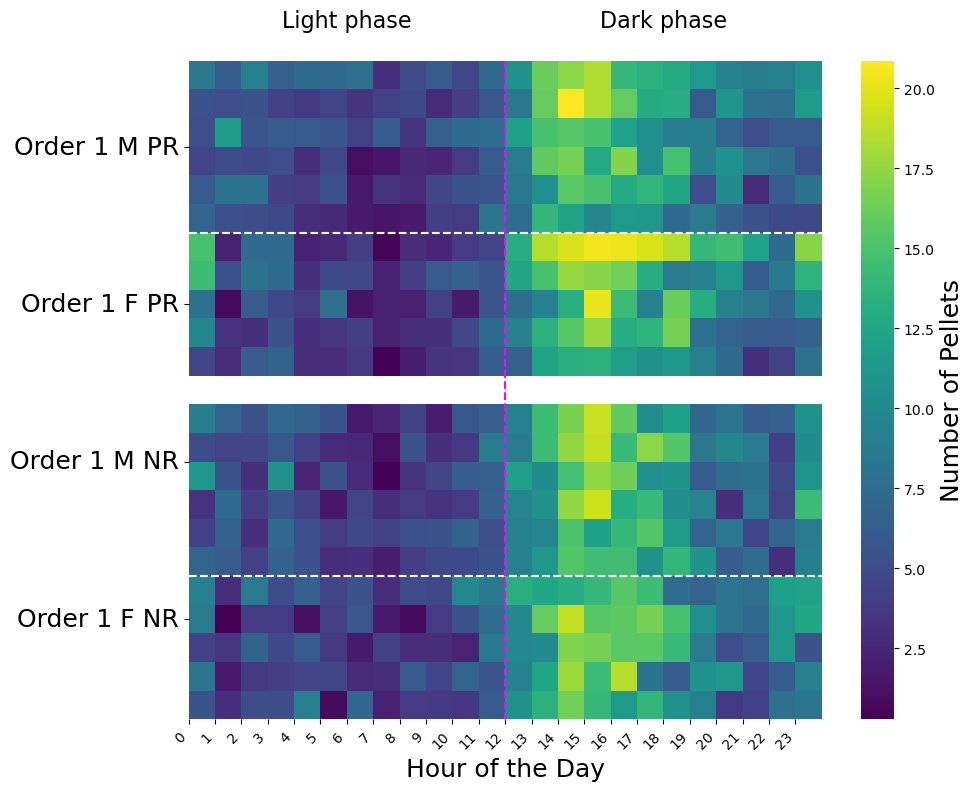

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Pellets'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 1, "sex": "M"}
nr_male_selector = {"order": 1, "sex": "M"}
pr_female_selector = {"order": 1, "sex": "F"}
nr_female_selector = {"order": 1, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_pellet_intake"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_pellet_intake"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_pellet_intake"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_pellet_intake"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 1 M PR", "Order 1 F PR", "Order 1 M NR", "Order 1 F NR"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary


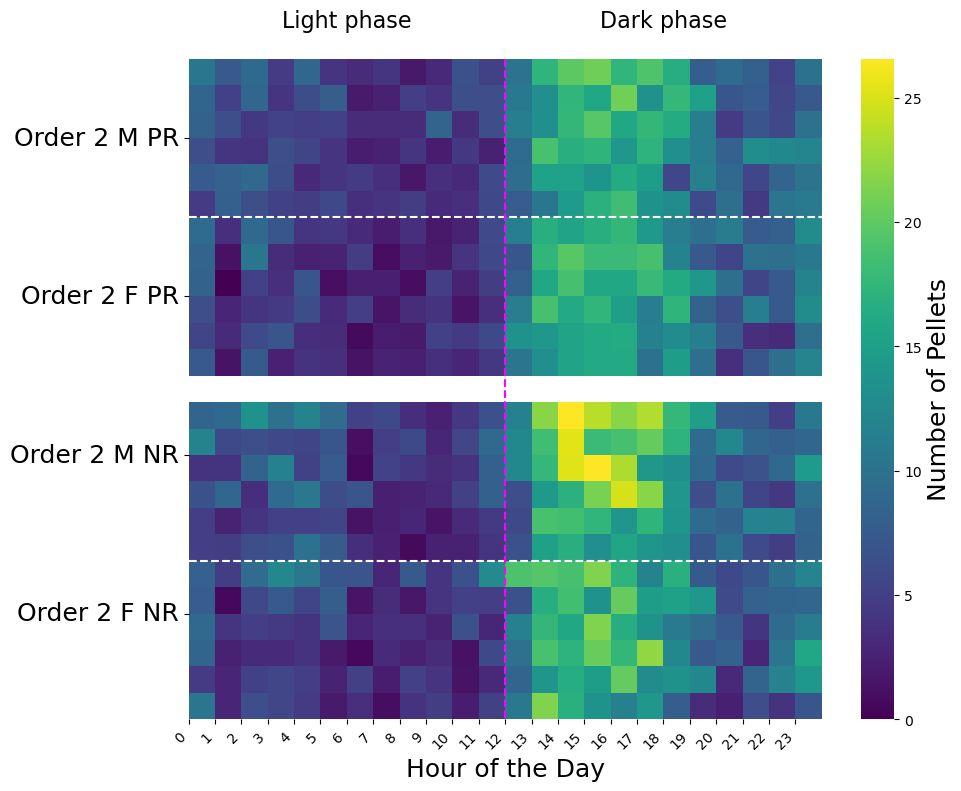

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Pellets'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 2, "sex": "M"}
nr_male_selector = {"order": 2, "sex": "M"}
pr_female_selector = {"order": 2, "sex": "F"}
nr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_pellet_intake"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_pellet_intake"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_pellet_intake"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_pellet_intake"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 2 M PR", "Order 2 F PR", "Order 2 M NR", "Order 2 F NR"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
5 items in output dictionary


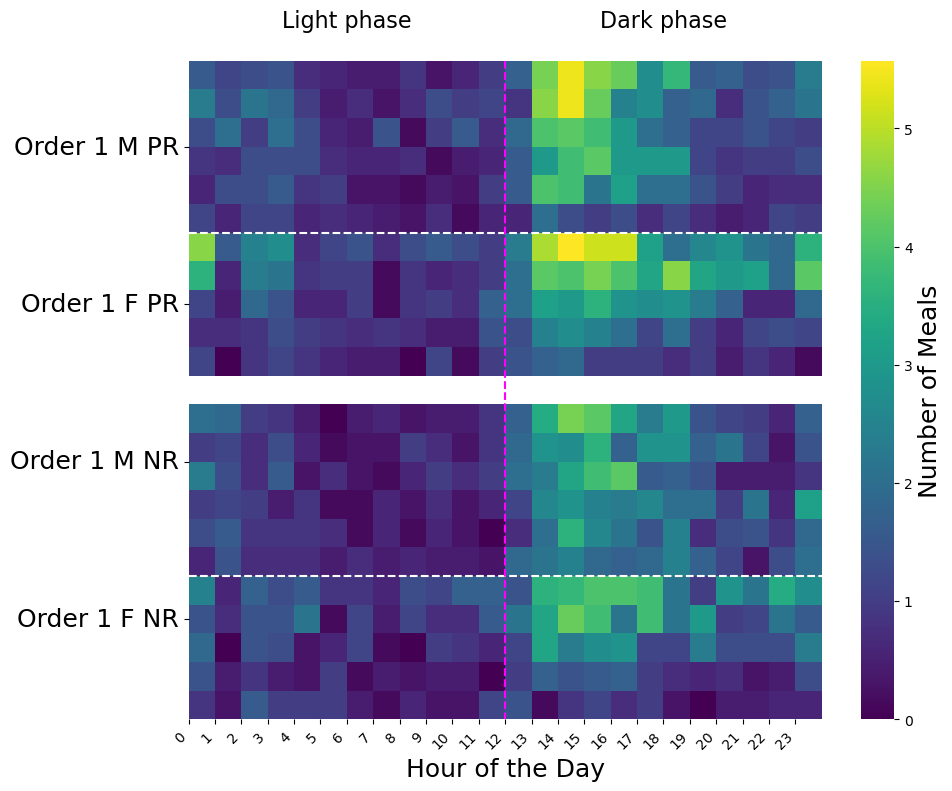

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Meals'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 1, "sex": "M"}
nr_male_selector = {"order": 1, "sex": "M"}
pr_female_selector = {"order": 1, "sex": "F"}
nr_female_selector = {"order": 1, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_meals"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_meals"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_meals"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_meals"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 1 M PR", "Order 1 F PR", "Order 1 M NR", "Order 1 F NR"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary


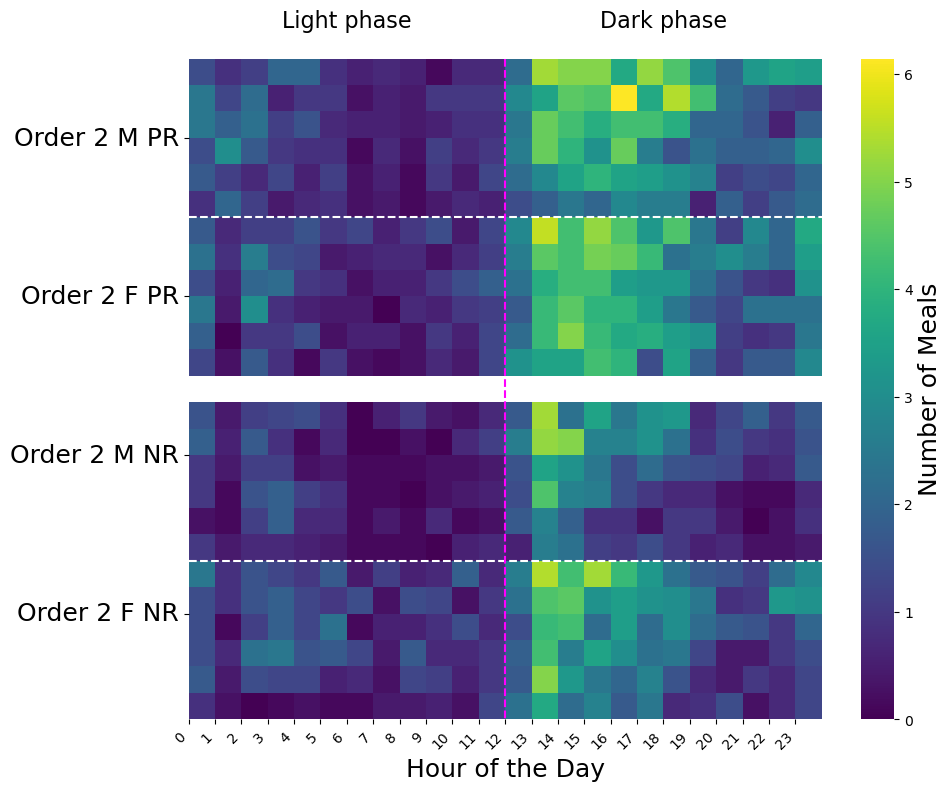

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Meals'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 2, "sex": "M"}
nr_male_selector = {"order": 2, "sex": "M"}
pr_female_selector = {"order": 2, "sex": "F"}
nr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_meals"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_meals"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_meals"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_meals"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 2 M PR", "Order 2 F PR", "Order 2 M NR", "Order 2 F NR"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
5 items in output dictionary


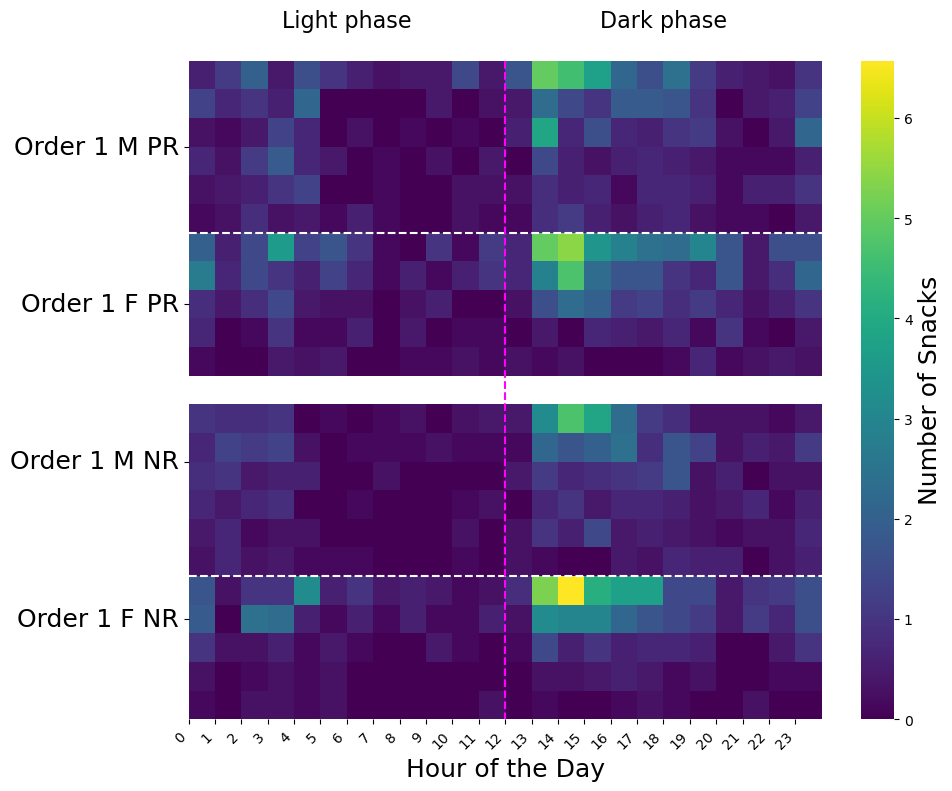

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Snacks'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 1, "sex": "M"}
nr_male_selector = {"order": 1, "sex": "M"}
pr_female_selector = {"order": 1, "sex": "F"}
nr_female_selector = {"order": 1, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_snacks"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_snacks"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_snacks"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_snacks"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 1 M PR", "Order 1 F PR", "Order 1 M NR", "Order 1 F NR"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary


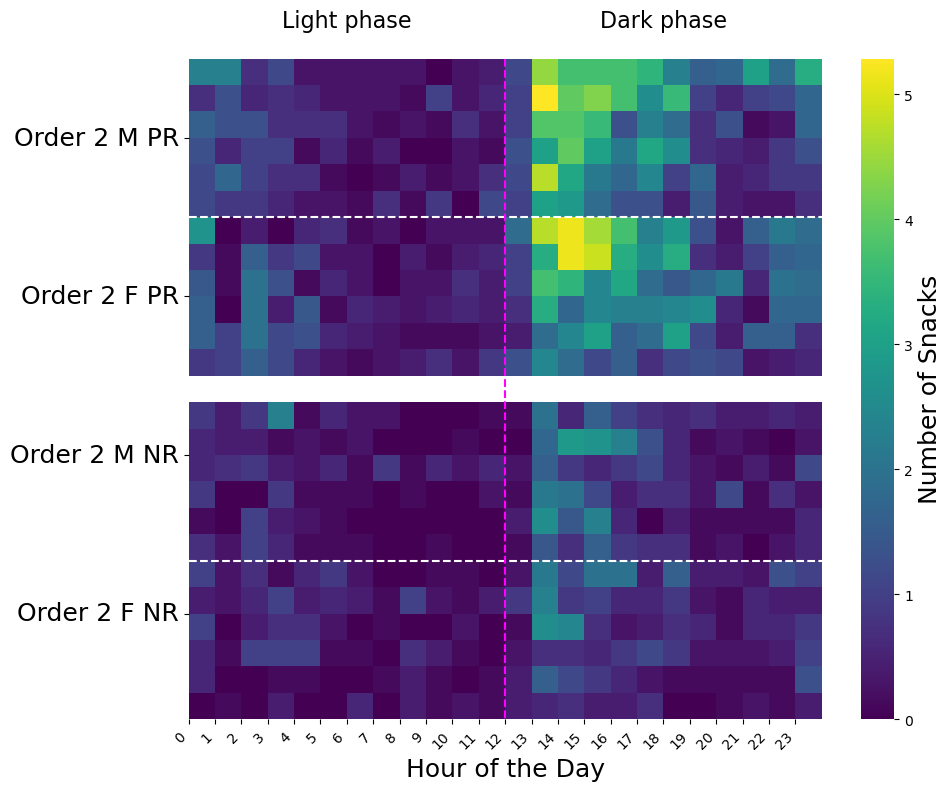

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Snacks'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 2, "sex": "M"}
nr_male_selector = {"order": 2, "sex": "M"}
pr_female_selector = {"order": 2, "sex": "F"}
nr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_snacks"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_snacks"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_snacks"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_snacks"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 2 M PR", "Order 2 F PR", "Order 2 M NR", "Order 2 F NR"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
5 items in output dictionary


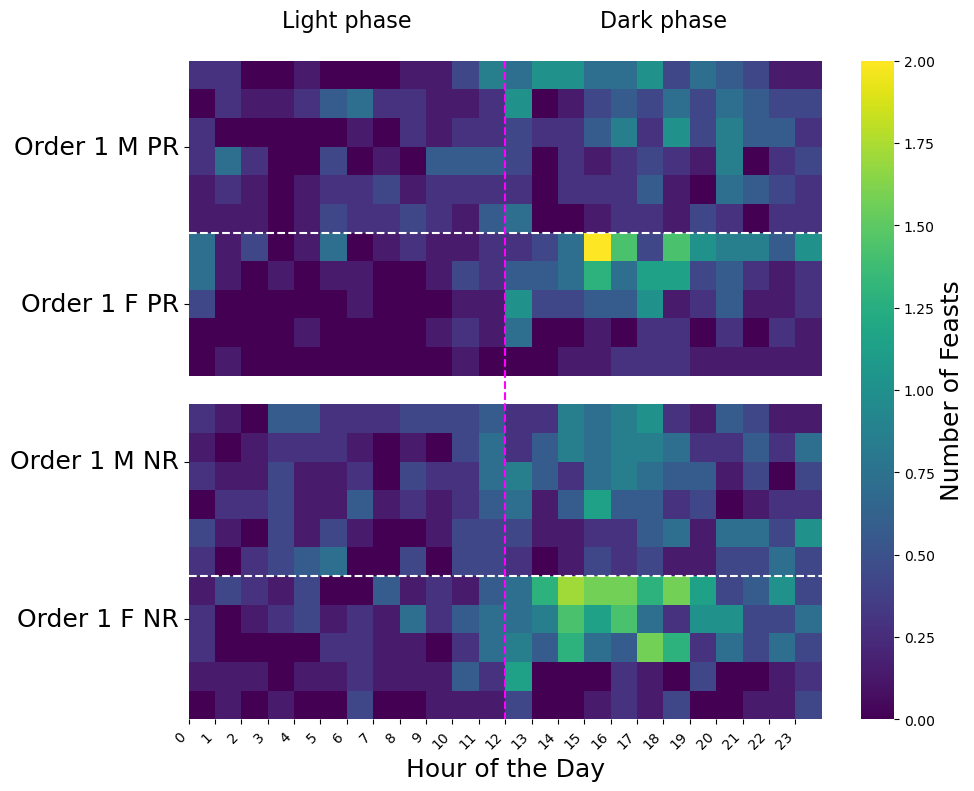

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Feasts'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 1, "sex": "M"}
nr_male_selector = {"order": 1, "sex": "M"}
pr_female_selector = {"order": 1, "sex": "F"}
nr_female_selector = {"order": 1, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_mega_meals"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_mega_meals"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_mega_meals"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_mega_meals"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 1 M PR", "Order 1 F PR", "Order 1 M NR", "Order 1 F NR"], tick_step=1)

plt.show()


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary


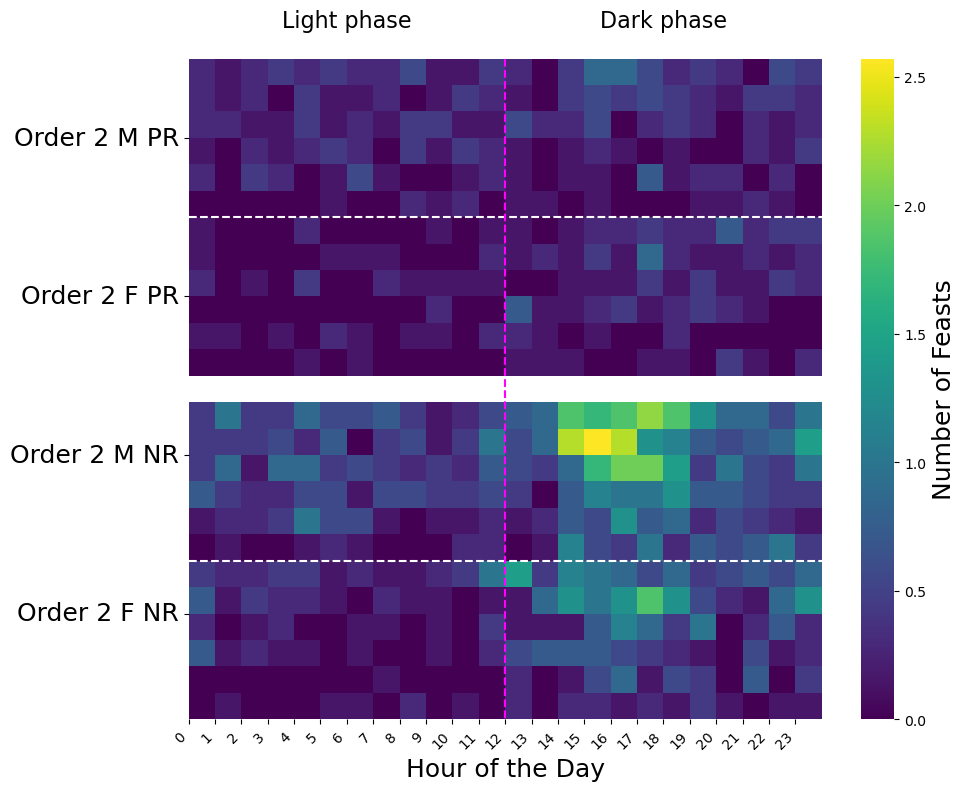

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 1 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 1).
    data_nr : list
        List containing NR diet data for male and female (Order 1).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 1 PR M", "Order 1 PR F", "Order 1 NR M", "Order 1 NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="viridis", cbar_kws={'label': 'Number of Feasts'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions, ensuring separation for each group
    group_lengths = [pr_male.shape[0], pr_female.shape[0], nr_male.shape[0], nr_female.shape[0]]
    y_positions = [sum(group_lengths[:i]) + length / 2 for i, length in enumerate(group_lengths)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 1 PR and NR male and female mice
pr_male_selector = {"order": 2, "sex": "M"}
nr_male_selector = {"order": 2, "sex": "M"}
pr_female_selector = {"order":2, "sex": "F"}
nr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_mega_meals"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_mega_meals"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_mega_meals"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_mega_meals"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 2 M PR", "Order 2 F PR", "Order 2 M NR", "Order 2 F NR"], tick_step=1)

plt.show()
